# TPC-H Collector Demo

# Missing
* connection data beyond loading
* join to connection data
* join to monitoring_single
* connection and configuration also in monitoring and connection df

## Naming
* There is an experiment having a code, say `1775855486`.
* The experiment inspects a SUT, say `PostgreSQL-A`. This is called a `configuration`.
* The experiment is run several times, say twice. The indicator of the run is called `experiment_run`.
* Each run can have several phases as a sequence. The number of the phase is called `client`. The state of the configuration in a phase is called a `connection`.
* Each client can have several `pods`, that are run in parallel. A pod represents a driver.
* Performance metrics are collected per driver pod.  
    The naming of an instance is `<sut>-<experiment_run>-<client>-<pod>`. It is unique per experiment.
* Monitoring metrics are collected per phase. They are automatically aggregated across parallel pods.  
    The naming of an instance is `<sut>-<experiment_run>-<client>`. It is unique per experiment.

## Aggregation
* Aggregation is complicated. Some metrics are aggregated via count, sum, max or average. Others cannot be aggregated sensibly, like experiment code or latency percentiles.
* There are helper functions to aggregated pods that are certainly run in parallel.  
  So `<sut>-<experiment_run>-<client>-<pod>` are aggregated to `<sut>-<experiment_run>-<client>`.
* An exception is multi-tenancy.

## Class `collector`
* constructor `collectors.benchbase(path, codes)`
* evaluator object `evaluate = collect.get_evaluator()`
* dataframe of connection infos `collect.get_connections()`
  * index is name of client
* **monitoring metrics**
  * dataframe of available metrics `collect.df_metrics`
    * index is key of metric
  * dataframe of monitored components `collect.get_monitored_phases()`
    * index is key of component
  * dataframe of aggregated metrics per connection `collect.get_monitoring_single_all()`
    * index is name of client
    * metrics aggregated per code, experiment_run and client
  * dataframe of aggregated metrics per connection and across tenants `collect.get_monitoring_all()`
    * index just enumerates
    * metrics aggregated per code, experiment_run and client and across tenants
  * dataframe of time series for a metric of a connection in an experiment `collect.get_monitoring_timeseries_single(code, metric)`
    * index is name of connection
    * unstacked (wide format)
  * dataframe of time series for a metric in all experiments `collect.get_monitoring_timeseries_all(metric)`
    * index just enumerates
    * stacked (long format)
* **performance metrics**
  * dataframe of loading metrics `collect.get_loading_time_max_all()`
    * index is name of client
  * dataframe of performance aggregated per parallel client `collect.get_performance_all()`
    * index just enumerates
    * performance aggregated per code, experiment_run and client
  * dataframe of performance for one experiment `collect.get_performance_single()`
    * performance of each single client (driver)
    * index is name of client pod
  * dataframe of performance for all experiments `collect.get_performance_all_single()`
    * performance of each single client (driver)
    * index is name of client pod


[1] [Benchmarking Multi-Tenant Architectures in PostgreSQL](https://doi.org/10.48786/edbt.2026.46)
> Erdelt, P.K., and Rabl T. (2026)
> In: Proceedings 29th International Conference on Extending Database Technology, EDBT 2026
> OpenProceedings.org
> https://doi.org/10.48786/edbt.2026.46


In [1]:
import pandas as pd
pd.set_option("display.max_rows", None)
pd.set_option('display.max_colwidth', None)

from bexhoma import collectors

%matplotlib inline

# Functions for Nice Plots

In [2]:
from notebookutils import *

# Collect Results

In [3]:
path = r"D:\data\benchmarks"
#path = r"/data/benchmarks"
filename_prefix = "demo_"
b_plot_save = False
b_skip_plots = True

In [4]:
codes = [
    "1775852722",
    "1775855486"
]

codes

['1775852722', '1775855486']

In [5]:
collect = collectors.benchbase(path, codes)

# Get all Metrics Metadata

## Metrics Names and Types

Metrics that are derived from monitoring

In [6]:
collect.df_metrics

,title,active,type,metric
total_cpu_memory,Memory Usage [MiB],True,cluster,gauge
total_cpu_memory_cached,Memory Usage Cached [MiB],True,cluster,gauge
total_cpu_util,CPU Utilization,True,cluster,gauge
total_cpu_throttled,CPU Throttle,True,cluster,gauge
total_cpu_throttled_s,CPU Throttled Time [s],True,cluster,counter
total_cpu_util_others,CPU Utilization Others,False,cluster,gauge
total_cpu_util_s,CPU Utilization Time [s],True,cluster,counter
total_cpu_util_user_s,CPU User Time [s],True,cluster,counter
total_cpu_util_sys_s,CPU System Time [s],True,cluster,counter
total_cpu_util_others_s,CPU Utilization Time Others [s],False,cluster,counter


## Names of Monitored Phases

Names of components and their phases

In [7]:
collect.get_monitored_phases()

,description
loading,Loading phase: SUT deployment
loader,Loading phase: component loader
stream,Execution phase: SUT deployment
benchmarker,Execution phase: component benchmarker


# Get Connection Infos

List of states of SUTs, containing loading infos.

In [8]:
collect.get_connections()['client'].iloc[0]

1

# Get Aggregated Metrics per SUT and per Experiment

In [9]:
df_performance = collect.get_monitoring_all(type="stream")
df_performance.T

,0,1,2,3,0,1,2,3
experiment_run,1,1,2,2,1,1,2,2
client,1,2,1,2,1,2,1,2
Memory Usage [MiB],9193.61,9872.4,9075.06,9869.83,9213.55,9939.76,9192.23,9874.04
Memory Usage Cached [MiB],11156.84,12384.32,11033.07,12401.17,11169.15,12492.83,11155.62,12415.73
CPU Utilization,7.25,7.13,7.38,6.89,6.95,6.78,6.71,6.59
CPU Throttle,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CPU Throttled Time [s],0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CPU Utilization Time [s],2578.09,2557.14,2639.5,2320.33,2119.83,2088.34,2148.79,2187.36
CPU User Time [s],1472.71,1456.08,1538.29,1347.28,1215.12,1194.67,1216.51,1243.81
CPU System Time [s],1105.38,1101.06,1101.21,973.06,904.71,893.67,932.27,943.54


# Bar Plots of Aggregated Values per Metric

In [10]:
if not b_skip_plots:
    for idx, row in collect.df_metrics.iterrows():
        if row["active"] == False:
            continue
        col_name = row["title"]
        plot_bars(df_performance, y=col_name, title=col_name, estimator='max', b_plot_save=b_plot_save, filename_prefix=filename_prefix)

# Boxplot of All Metrics for a Single Experiment

In [11]:
if not b_skip_plots:
    results = []
    code = codes[0]
    for idx, row in collect.df_metrics.iterrows():
        if row["active"] == False:
            continue
        metric_name = idx
        method = 'diff' if row["metric"] == 'counter' else 'mean'
        col_name = row["title"]
        df_monitoring = collect.get_monitoring_timeseries_single(code, metric=metric_name)
        #print(df_monitoring)
        ax = df_monitoring.boxplot()
        ax.set_title(col_name)
        plt.show()

# Boxplot of A Single Metric for a Single Experiment

In [12]:
metric = 'total_cpu_memory'
code = codes[0]
collect.get_monitoring_timeseries_single(code, metric=metric)

,PostgreSQL-1-1-1024-1-1,PostgreSQL-1-1-1024-1-2,PostgreSQL-1-1-1024-2-1,PostgreSQL-1-1-1024-2-2
0,7576.824219,8234.519531,7575.898438,8237.324219
1,7576.824219,8234.519531,7575.898438,8237.324219
2,7576.824219,8234.519531,7575.898438,8237.324219
3,7576.824219,8234.519531,7575.898438,8237.324219
4,7576.824219,8234.519531,7575.898438,8237.324219
5,7576.824219,8234.519531,7575.898438,8237.324219
6,7576.824219,9163.679688,7575.898438,8237.324219
7,7576.824219,9163.679688,7575.898438,8237.324219
8,7576.824219,9163.679688,7575.898438,8237.324219
9,7576.824219,9163.679688,7575.898438,8237.324219


In [13]:
metric = 'total_cpu_memory'
code = codes[0]
collect.get_monitoring_timeseries_all( metric=metric)

,timestamp,code,experiment_run,client,type,vol_tenants,num_tenants,value
0,0,1775852722,1,1,None,False,0,7576.824219
1,0,1775852722,1,2,None,False,0,8234.519531
2,0,1775852722,2,1,None,False,0,7575.898438
3,0,1775852722,2,2,None,False,0,8237.324219
4,0,1775855486,1,1,None,False,0,7590.890625
5,0,1775855486,1,2,None,False,0,8244.476562
6,0,1775855486,2,1,None,False,0,7576.128906
7,0,1775855486,2,2,None,False,0,8233.695312
8,1,1775852722,1,1,None,False,0,7576.824219
9,1,1775852722,1,2,None,False,0,8234.519531


In [14]:
if not b_skip_plots:
    metric = 'pg_stat_activity_max_tx_duration_active'
    #metric = 'pg_stat_database_blks_reads'
    #metric = 'pg_stat_activity_count_idle_transaction'
    metric = 'total_cpu_memory'
    code = codes[0]
    df_monitoring = collect.get_monitoring_timeseries_single(code, metric=metric)
    ax = df_monitoring.boxplot()
    ax.set_title(collect.df_metrics.loc[metric]['title'])#metric)
    plt.show()
    df_monitoring

# Lineplot of a Single Metric for a Single Experiment

In [15]:
if not b_skip_plots:
    code = codes[0]
    metric = 'pg_stat_database_blks_hit'
    metric = 'pg_stat_activity_count_idle_transaction'
    metric = 'total_cpu_memory'
    metric = 'total_cpu_util'
    metric = 'total_cpu_util_s'
    metric = 'core_variance'
    df_monitoring = collect.get_monitoring_timeseries_single(code, metric=metric)
    ax = df_monitoring.plot()
    ax.set_title(metric)
    plt.show()
    #df_monitoring

# Boxplot of a Single Metric for all Experiments

In [16]:
metric = 'pg_stat_database_blks_hit'
metric = 'pg_stat_activity_count_idle_transaction'
metric = 'total_cpu_memory'
metric = 'total_cpu_util'
metric = 'total_cpu_util_s'
metric = 'core_variance'
metric = 'pg_locks_count_exclusivelock'
metric = 'pg_stat_activity_count_active'
df_performance = collect.get_monitoring_timeseries_all(metric)
#df_performance
df_performance_first = df_performance[df_performance['client']=="1"]
#df_performance_first
df_performance_second = df_performance[df_performance['client']=="2"]
#df_performance_second
#df_performance_first['value'].describe()
#df_performance

## First Execution Run

C:\Users\Patrick\eclipse-workspace\Benchmark-Experiment-Host-Manager\dev\notebookutils.py:165: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Type")
C:\Users\Patrick\eclipse-workspace\Benchmark-Experiment-Host-Manager\dev\notebookutils.py:166: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=18)


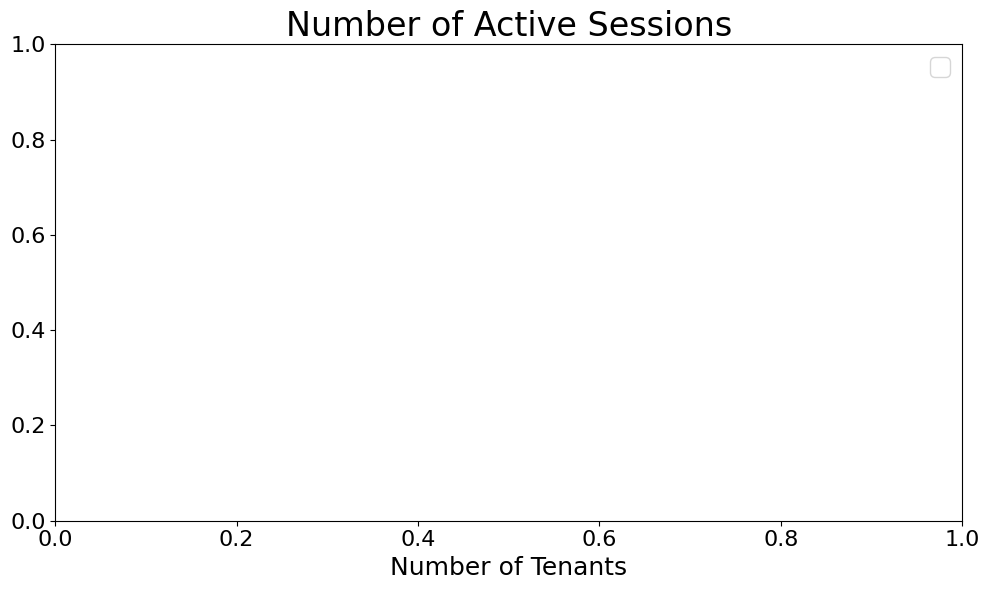

In [17]:
plot_boxplots(df_performance_first, y='value', title=collect.df_metrics.loc[metric]['title'], b_plot_save=b_plot_save, filename_prefix=filename_prefix)

## Second Execution Run

C:\Users\Patrick\eclipse-workspace\Benchmark-Experiment-Host-Manager\dev\notebookutils.py:165: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Type")
C:\Users\Patrick\eclipse-workspace\Benchmark-Experiment-Host-Manager\dev\notebookutils.py:166: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=18)


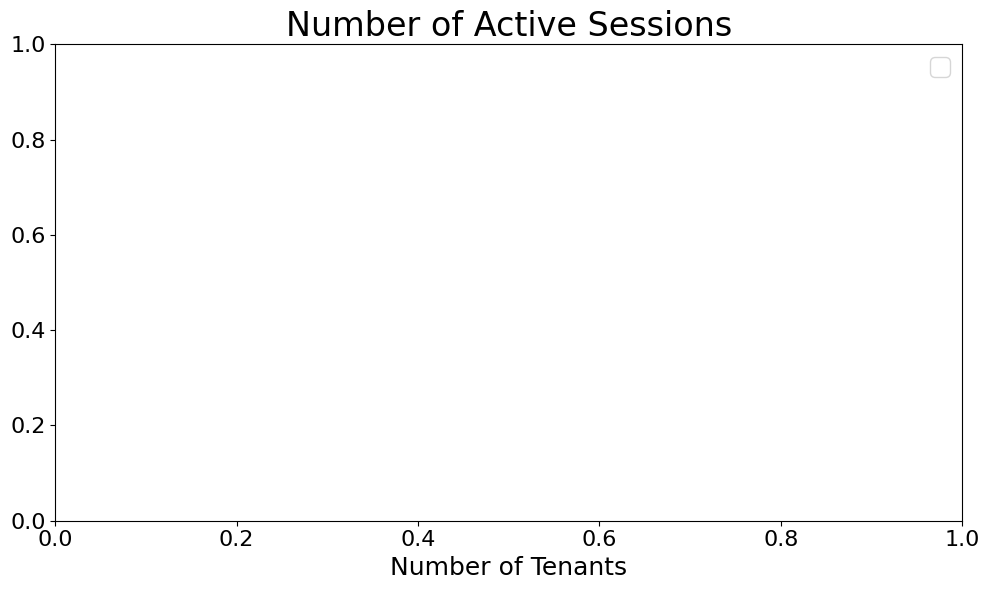

In [18]:
plot_boxplots(df_performance_second, y='value', title=collect.df_metrics.loc[metric]['title'], b_plot_save=b_plot_save, filename_prefix=filename_prefix)

# Lineplot of a Single Metric for All Experiments

## First Execution Run

C:\Users\Patrick\eclipse-workspace\Benchmark-Experiment-Host-Manager\dev\notebookutils.py:187: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  ax = sns.lineplot(


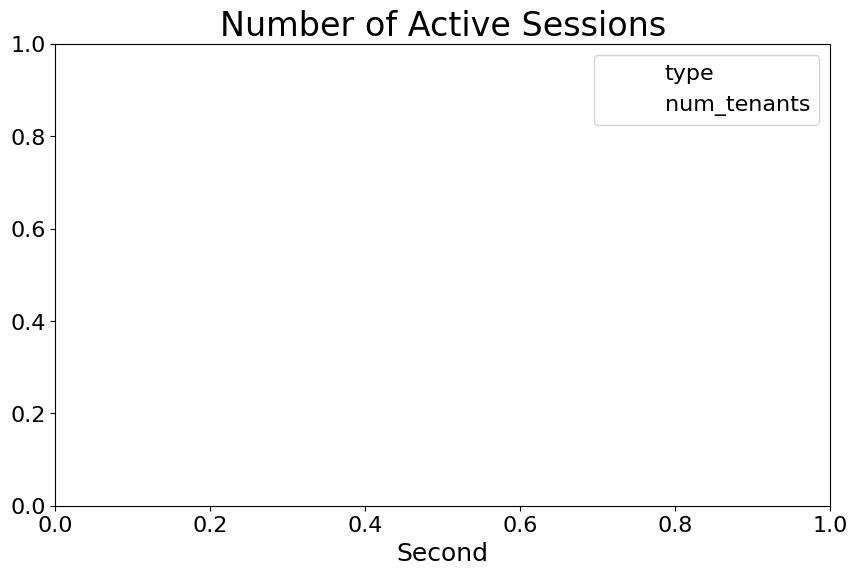

In [19]:
#df = df_performance_first[df_performance_first['type'] == 'None']
#df = df[df['experiment_run'] == '1']
plot_lines(df_performance_first, y='value', title=collect.df_metrics.loc[metric]['title'], b_plot_save=b_plot_save, filename_prefix=filename_prefix)
#df

# Aggregated Metrics for all Connections

In [20]:
df_performance = collect.get_monitoring_single_all("stream")
df_performance.T

,PostgreSQL-1-1-1024-1-1,PostgreSQL-1-1-1024-1-2,PostgreSQL-1-1-1024-2-1,PostgreSQL-1-1-1024-2-2,PostgreSQL-1-1-1024-1-1,PostgreSQL-1-1-1024-1-2,PostgreSQL-1-1-1024-2-1,PostgreSQL-1-1-1024-2-2
Memory Usage [MiB],9193.61,9872.4,9075.06,9869.83,9213.55,9939.76,9192.23,9874.04
Memory Usage Cached [MiB],11156.84,12384.32,11033.07,12401.17,11169.15,12492.83,11155.62,12415.73
CPU Utilization,7.25,7.13,7.38,6.89,6.95,6.78,6.71,6.59
CPU Throttle,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CPU Throttled Time [s],0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CPU Utilization Time [s],2578.09,2557.14,2639.5,2320.33,2119.83,2088.34,2148.79,2187.36
CPU User Time [s],1472.71,1456.08,1538.29,1347.28,1215.12,1194.67,1216.51,1243.81
CPU System Time [s],1105.38,1101.06,1101.21,973.06,904.71,893.67,932.27,943.54
Network Rx Total [MiB],3965.11,2230.61,3955.69,1651.63,3756.65,1799.33,3557.06,1781.43
Network Tx Total [MiB],2948.03,1934.05,3395.2,1732.26,3170.12,2044.35,2602.92,1740.33


# Monitoring Aggregated Values

In [21]:
df_performance = collect.get_monitoring_all("stream")

df_performance_first = df_performance[df_performance['client']==1]
df_performance_second = df_performance[df_performance['client']==2]

df_performance.T#[['Max CPU', 'client', 'type', 'num_tenants']]

,0,1,2,3,0,1,2,3
experiment_run,1,1,2,2,1,1,2,2
client,1,2,1,2,1,2,1,2
Memory Usage [MiB],9193.61,9872.4,9075.06,9869.83,9213.55,9939.76,9192.23,9874.04
Memory Usage Cached [MiB],11156.84,12384.32,11033.07,12401.17,11169.15,12492.83,11155.62,12415.73
CPU Utilization,7.25,7.13,7.38,6.89,6.95,6.78,6.71,6.59
CPU Throttle,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CPU Throttled Time [s],0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CPU Utilization Time [s],2578.09,2557.14,2639.5,2320.33,2119.83,2088.34,2148.79,2187.36
CPU User Time [s],1472.71,1456.08,1538.29,1347.28,1215.12,1194.67,1216.51,1243.81
CPU System Time [s],1105.38,1101.06,1101.21,973.06,904.71,893.67,932.27,943.54


## First Execution Run

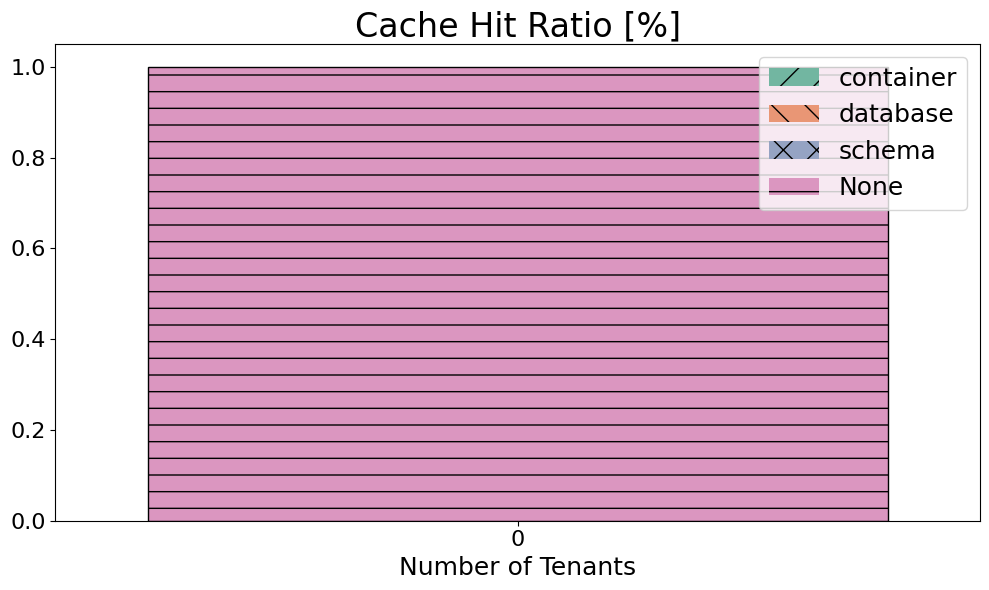

In [22]:
plot_bars(df_performance_first, y='Buffer Cache Hit Ratio', title='Cache Hit Ratio [%]', estimator='min', b_plot_save=b_plot_save, filename_prefix=filename_prefix)

## Second Execution Run

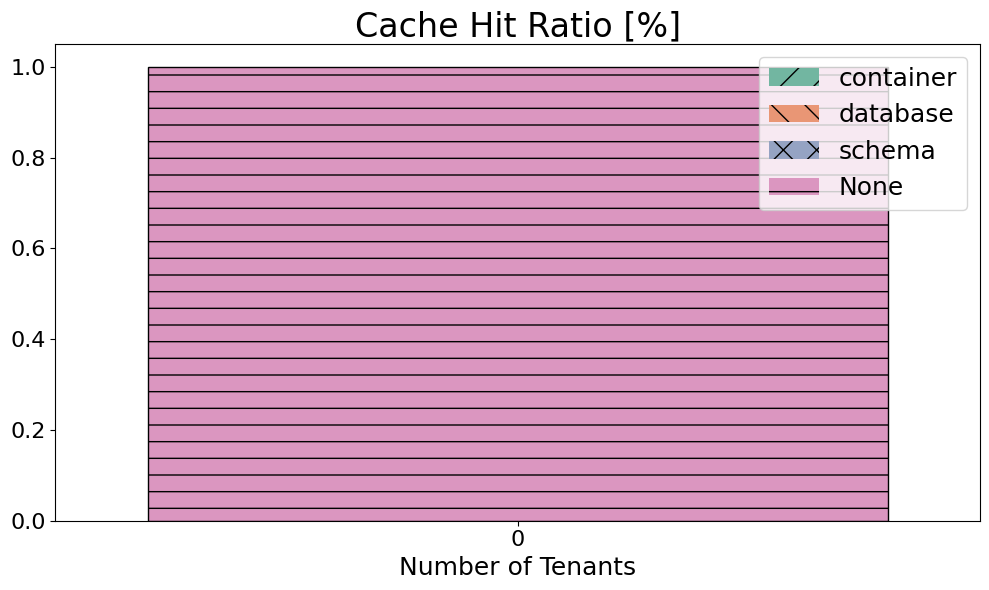

In [23]:
plot_bars(df_performance_second, y='Buffer Cache Hit Ratio', title='Cache Hit Ratio [%]', estimator='min', b_plot_save=b_plot_save, filename_prefix=filename_prefix)

# Performance Results per Tenant

In [24]:
df_performance = collect.get_performance_all_single()

df_performance_first = df_performance[df_performance['client']==1]
df_performance_second = df_performance[df_performance['client']==2]

df_performance.T

connection_pod,PostgreSQL-1-1-1024-1-1-1,PostgreSQL-1-1-1024-1-2-1,PostgreSQL-1-1-1024-1-2-2,PostgreSQL-1-1-1024-2-1-1,PostgreSQL-1-1-1024-2-2-1,PostgreSQL-1-1-1024-2-2-2,PostgreSQL-1-1-1024-1-1-1,PostgreSQL-1-1-1024-1-1-2,PostgreSQL-1-1-1024-1-1-3,PostgreSQL-1-1-1024-1-1-4,...,PostgreSQL-1-1-1024-2-1-3,PostgreSQL-1-1-1024-2-1-4,PostgreSQL-1-1-1024-2-2-1,PostgreSQL-1-1-1024-2-2-2,PostgreSQL-1-1-1024-2-2-3,PostgreSQL-1-1-1024-2-2-4,PostgreSQL-1-1-1024-2-2-5,PostgreSQL-1-1-1024-2-2-6,PostgreSQL-1-1-1024-2-2-7,PostgreSQL-1-1-1024-2-2-8
connection,PostgreSQL-1-1-1024-1-1,PostgreSQL-1-1-1024-1-2,PostgreSQL-1-1-1024-1-2,PostgreSQL-1-1-1024-2-1,PostgreSQL-1-1-1024-2-2,PostgreSQL-1-1-1024-2-2,PostgreSQL-1-1-1024-1-1,PostgreSQL-1-1-1024-1-1,PostgreSQL-1-1-1024-1-1,PostgreSQL-1-1-1024-1-1,...,PostgreSQL-1-1-1024-2-1,PostgreSQL-1-1-1024-2-1,PostgreSQL-1-1-1024-2-2,PostgreSQL-1-1-1024-2-2,PostgreSQL-1-1-1024-2-2,PostgreSQL-1-1-1024-2-2,PostgreSQL-1-1-1024-2-2,PostgreSQL-1-1-1024-2-2,PostgreSQL-1-1-1024-2-2,PostgreSQL-1-1-1024-2-2
configuration,PostgreSQL-1-1-1024,PostgreSQL-1-1-1024,PostgreSQL-1-1-1024,PostgreSQL-1-1-1024,PostgreSQL-1-1-1024,PostgreSQL-1-1-1024,PostgreSQL-1-1-1024,PostgreSQL-1-1-1024,PostgreSQL-1-1-1024,PostgreSQL-1-1-1024,...,PostgreSQL-1-1-1024,PostgreSQL-1-1-1024,PostgreSQL-1-1-1024,PostgreSQL-1-1-1024,PostgreSQL-1-1-1024,PostgreSQL-1-1-1024,PostgreSQL-1-1-1024,PostgreSQL-1-1-1024,PostgreSQL-1-1-1024,PostgreSQL-1-1-1024
experiment_run,1,1,1,2,2,2,1,1,1,1,...,2,2,2,2,2,2,2,2,2,2
code,1775852722,1775852722,1775852722,1775852722,1775852722,1775852722,1775855486,1775855486,1775855486,1775855486,...,1775855486,1775855486,1775855486,1775855486,1775855486,1775855486,1775855486,1775855486,1775855486,1775855486
client,1,2,2,1,2,2,1,1,1,1,...,1,1,2,2,2,2,2,2,2,2
pod,kljq4.dbmsbenchmarker,m8gls.dbmsbenchmarker,nvpdg.dbmsbenchmarker,dfwqk.dbmsbenchmarker,6j9x2.dbmsbenchmarker,8pv6v.dbmsbenchmarker,cvnpd.dbmsbenchmarker,h6qss.dbmsbenchmarker,schkb.dbmsbenchmarker,z28zb.dbmsbenchmarker,...,qhcl8.dbmsbenchmarker,t242d.dbmsbenchmarker,9mnjp.dbmsbenchmarker,c6l7n.dbmsbenchmarker,g6288.dbmsbenchmarker,mklcl.dbmsbenchmarker,nsh6m.dbmsbenchmarker,phbzp.dbmsbenchmarker,r5lpc.dbmsbenchmarker,xgnsx.dbmsbenchmarker
pod_count,1,2,2,1,2,2,4,4,4,4,...,4,4,8,8,8,8,8,8,8,8
bench,tpcc,tpcc,tpcc,tpcc,tpcc,tpcc,tpcc,tpcc,tpcc,tpcc,...,tpcc,tpcc,tpcc,tpcc,tpcc,tpcc,tpcc,tpcc,tpcc,tpcc
profile,postgres,postgres,postgres,postgres,postgres,postgres,postgres,postgres,postgres,postgres,...,postgres,postgres,postgres,postgres,postgres,postgres,postgres,postgres,postgres,postgres
target,16384,8192,8192,16384,8192,8192,5120,5120,5120,5120,...,5120,5120,2560,2560,2560,2560,2560,2560,2560,2560


## First Execution Run

C:\Users\Patrick\eclipse-workspace\Benchmark-Experiment-Host-Manager\dev\notebookutils.py:165: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Type")
C:\Users\Patrick\eclipse-workspace\Benchmark-Experiment-Host-Manager\dev\notebookutils.py:166: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=18)


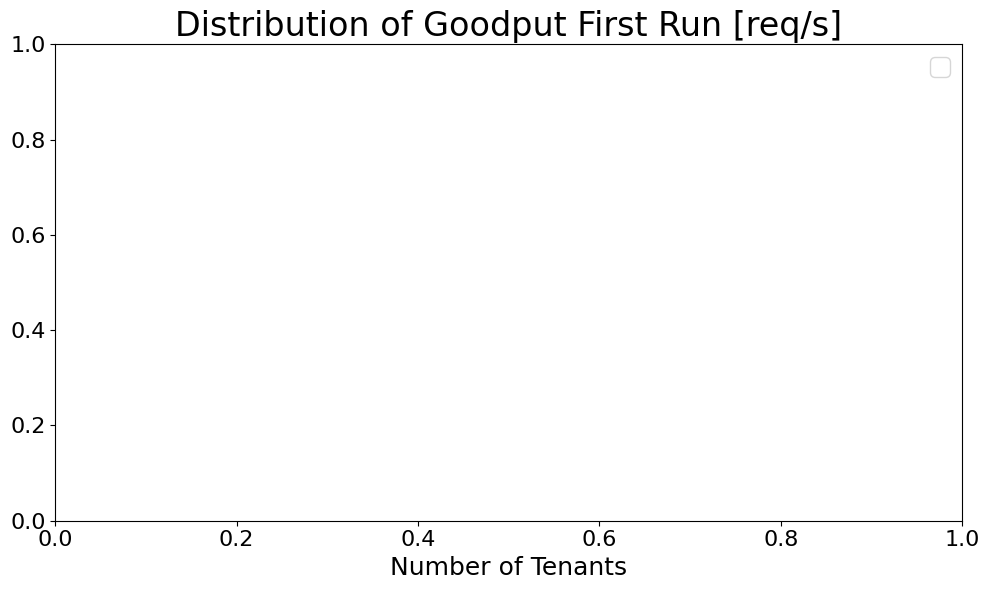

In [25]:
plot_boxplots(df_performance_first, y='Goodput (requests/second)', title='Distribution of Goodput First Run [req/s]', b_plot_save=b_plot_save, filename_prefix=filename_prefix)

C:\Users\Patrick\eclipse-workspace\Benchmark-Experiment-Host-Manager\dev\notebookutils.py:165: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Type")
C:\Users\Patrick\eclipse-workspace\Benchmark-Experiment-Host-Manager\dev\notebookutils.py:166: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=18)


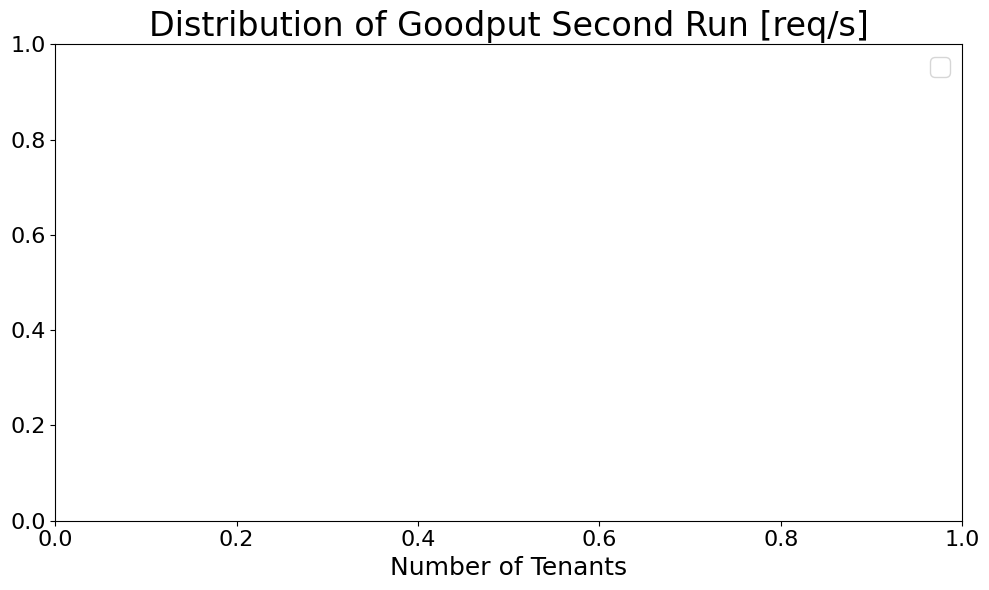

In [26]:
plot_boxplots(df_performance_second, y='Goodput (requests/second)', title='Distribution of Goodput Second Run [req/s]', b_plot_save=b_plot_save, filename_prefix=filename_prefix)

C:\Users\Patrick\eclipse-workspace\Benchmark-Experiment-Host-Manager\dev\notebookutils.py:165: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Type")
C:\Users\Patrick\eclipse-workspace\Benchmark-Experiment-Host-Manager\dev\notebookutils.py:166: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=18)


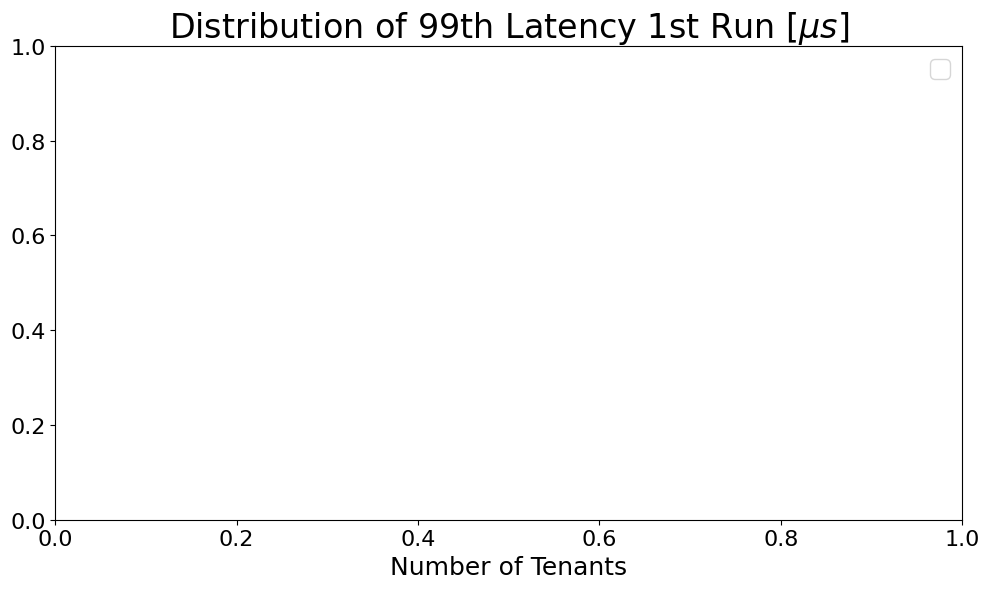

In [27]:
plot_boxplots(df_performance_first, y='Latency Distribution.99th Percentile Latency (microseconds)', title=r'Distribution of 99th Latency 1st Run [$\mu s$]', b_plot_save=b_plot_save, filename_prefix=filename_prefix)

C:\Users\Patrick\eclipse-workspace\Benchmark-Experiment-Host-Manager\dev\notebookutils.py:165: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Type")
C:\Users\Patrick\eclipse-workspace\Benchmark-Experiment-Host-Manager\dev\notebookutils.py:166: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=18)


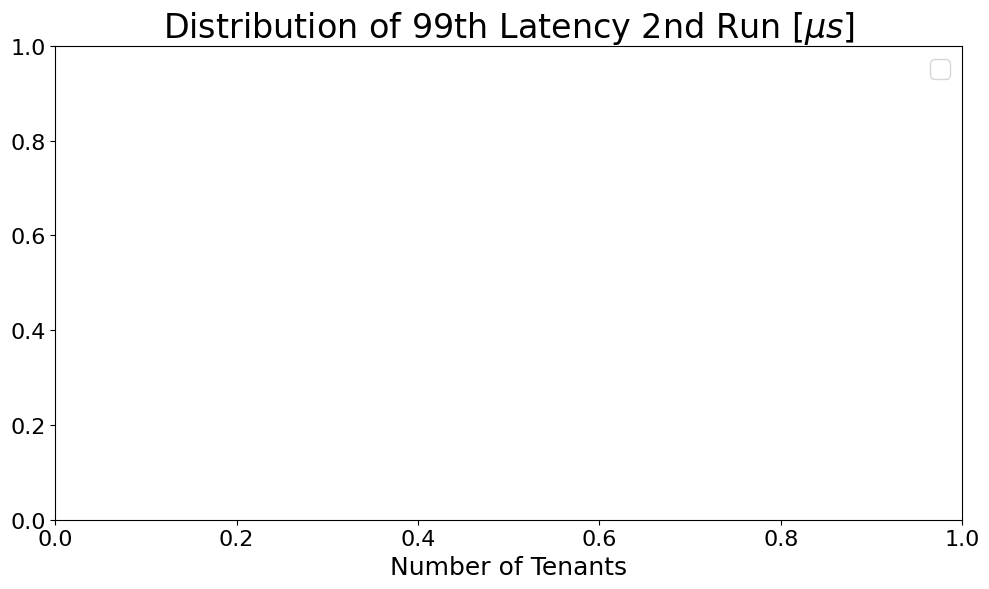

In [28]:
plot_boxplots(df_performance_second, y='Latency Distribution.99th Percentile Latency (microseconds)', title=r'Distribution of 99th Latency 2nd Run [$\mu s$]', b_plot_save=b_plot_save, filename_prefix=filename_prefix)

# Performance Results per Total

In [29]:
collect.get_performance_single().T

connection_pod,PostgreSQL-1-1-1024-1-1-1,PostgreSQL-1-1-1024-1-2-1,PostgreSQL-1-1-1024-1-2-2,PostgreSQL-1-1-1024-2-1-1,PostgreSQL-1-1-1024-2-2-1,PostgreSQL-1-1-1024-2-2-2
connection,PostgreSQL-1-1-1024-1-1,PostgreSQL-1-1-1024-1-2,PostgreSQL-1-1-1024-1-2,PostgreSQL-1-1-1024-2-1,PostgreSQL-1-1-1024-2-2,PostgreSQL-1-1-1024-2-2
configuration,PostgreSQL-1-1-1024,PostgreSQL-1-1-1024,PostgreSQL-1-1-1024,PostgreSQL-1-1-1024,PostgreSQL-1-1-1024,PostgreSQL-1-1-1024
experiment_run,1,1,1,2,2,2
code,1775852722,1775852722,1775852722,1775852722,1775852722,1775852722
client,1,2,2,1,2,2
pod,kljq4.dbmsbenchmarker,m8gls.dbmsbenchmarker,nvpdg.dbmsbenchmarker,dfwqk.dbmsbenchmarker,6j9x2.dbmsbenchmarker,8pv6v.dbmsbenchmarker
pod_count,1,2,2,1,2,2
bench,tpcc,tpcc,tpcc,tpcc,tpcc,tpcc
profile,postgres,postgres,postgres,postgres,postgres,postgres
target,16384,8192,8192,16384,8192,8192


In [30]:
collect.get_performance_all_single().T

connection_pod,PostgreSQL-1-1-1024-1-1-1,PostgreSQL-1-1-1024-1-2-1,PostgreSQL-1-1-1024-1-2-2,PostgreSQL-1-1-1024-2-1-1,PostgreSQL-1-1-1024-2-2-1,PostgreSQL-1-1-1024-2-2-2,PostgreSQL-1-1-1024-1-1-1,PostgreSQL-1-1-1024-1-1-2,PostgreSQL-1-1-1024-1-1-3,PostgreSQL-1-1-1024-1-1-4,...,PostgreSQL-1-1-1024-2-1-3,PostgreSQL-1-1-1024-2-1-4,PostgreSQL-1-1-1024-2-2-1,PostgreSQL-1-1-1024-2-2-2,PostgreSQL-1-1-1024-2-2-3,PostgreSQL-1-1-1024-2-2-4,PostgreSQL-1-1-1024-2-2-5,PostgreSQL-1-1-1024-2-2-6,PostgreSQL-1-1-1024-2-2-7,PostgreSQL-1-1-1024-2-2-8
connection,PostgreSQL-1-1-1024-1-1,PostgreSQL-1-1-1024-1-2,PostgreSQL-1-1-1024-1-2,PostgreSQL-1-1-1024-2-1,PostgreSQL-1-1-1024-2-2,PostgreSQL-1-1-1024-2-2,PostgreSQL-1-1-1024-1-1,PostgreSQL-1-1-1024-1-1,PostgreSQL-1-1-1024-1-1,PostgreSQL-1-1-1024-1-1,...,PostgreSQL-1-1-1024-2-1,PostgreSQL-1-1-1024-2-1,PostgreSQL-1-1-1024-2-2,PostgreSQL-1-1-1024-2-2,PostgreSQL-1-1-1024-2-2,PostgreSQL-1-1-1024-2-2,PostgreSQL-1-1-1024-2-2,PostgreSQL-1-1-1024-2-2,PostgreSQL-1-1-1024-2-2,PostgreSQL-1-1-1024-2-2
configuration,PostgreSQL-1-1-1024,PostgreSQL-1-1-1024,PostgreSQL-1-1-1024,PostgreSQL-1-1-1024,PostgreSQL-1-1-1024,PostgreSQL-1-1-1024,PostgreSQL-1-1-1024,PostgreSQL-1-1-1024,PostgreSQL-1-1-1024,PostgreSQL-1-1-1024,...,PostgreSQL-1-1-1024,PostgreSQL-1-1-1024,PostgreSQL-1-1-1024,PostgreSQL-1-1-1024,PostgreSQL-1-1-1024,PostgreSQL-1-1-1024,PostgreSQL-1-1-1024,PostgreSQL-1-1-1024,PostgreSQL-1-1-1024,PostgreSQL-1-1-1024
experiment_run,1,1,1,2,2,2,1,1,1,1,...,2,2,2,2,2,2,2,2,2,2
code,1775852722,1775852722,1775852722,1775852722,1775852722,1775852722,1775855486,1775855486,1775855486,1775855486,...,1775855486,1775855486,1775855486,1775855486,1775855486,1775855486,1775855486,1775855486,1775855486,1775855486
client,1,2,2,1,2,2,1,1,1,1,...,1,1,2,2,2,2,2,2,2,2
pod,kljq4.dbmsbenchmarker,m8gls.dbmsbenchmarker,nvpdg.dbmsbenchmarker,dfwqk.dbmsbenchmarker,6j9x2.dbmsbenchmarker,8pv6v.dbmsbenchmarker,cvnpd.dbmsbenchmarker,h6qss.dbmsbenchmarker,schkb.dbmsbenchmarker,z28zb.dbmsbenchmarker,...,qhcl8.dbmsbenchmarker,t242d.dbmsbenchmarker,9mnjp.dbmsbenchmarker,c6l7n.dbmsbenchmarker,g6288.dbmsbenchmarker,mklcl.dbmsbenchmarker,nsh6m.dbmsbenchmarker,phbzp.dbmsbenchmarker,r5lpc.dbmsbenchmarker,xgnsx.dbmsbenchmarker
pod_count,1,2,2,1,2,2,4,4,4,4,...,4,4,8,8,8,8,8,8,8,8
bench,tpcc,tpcc,tpcc,tpcc,tpcc,tpcc,tpcc,tpcc,tpcc,tpcc,...,tpcc,tpcc,tpcc,tpcc,tpcc,tpcc,tpcc,tpcc,tpcc,tpcc
profile,postgres,postgres,postgres,postgres,postgres,postgres,postgres,postgres,postgres,postgres,...,postgres,postgres,postgres,postgres,postgres,postgres,postgres,postgres,postgres,postgres
target,16384,8192,8192,16384,8192,8192,5120,5120,5120,5120,...,5120,5120,2560,2560,2560,2560,2560,2560,2560,2560


In [31]:
df_performance = collect.get_performance_all()

df_performance_first = df_performance[df_performance['client']==1]
df_performance_second = df_performance[df_performance['client']==2]

df_performance.dropna(inplace=True)

In [32]:
df_performance.T

,PostgreSQL-1-1-1024-1-1,PostgreSQL-1-1-1024-1-2,PostgreSQL-1-1-1024-2-1,PostgreSQL-1-1-1024-2-2,PostgreSQL-1-1-1024-1-1,PostgreSQL-1-1-1024-1-2,PostgreSQL-1-1-1024-2-1,PostgreSQL-1-1-1024-2-2
connection,PostgreSQL-1-1-1024-1-1,PostgreSQL-1-1-1024-1-2,PostgreSQL-1-1-1024-2-1,PostgreSQL-1-1-1024-2-2,PostgreSQL-1-1-1024-1-1,PostgreSQL-1-1-1024-1-2,PostgreSQL-1-1-1024-2-1,PostgreSQL-1-1-1024-2-2
configuration,PostgreSQL-1-1-1024,PostgreSQL-1-1-1024,PostgreSQL-1-1-1024,PostgreSQL-1-1-1024,PostgreSQL-1-1-1024,PostgreSQL-1-1-1024,PostgreSQL-1-1-1024,PostgreSQL-1-1-1024
experiment_run,1,1,2,2,1,1,2,2
client,1,2,1,2,1,2,1,2
code,1775852722,1775852722,1775852722,1775852722,1775855486,1775855486,1775855486,1775855486
pod,kljq4.dbmsbenchmarker,m8gls.dbmsbenchmarkernvpdg.dbmsbenchmarker,dfwqk.dbmsbenchmarker,6j9x2.dbmsbenchmarker8pv6v.dbmsbenchmarker,cvnpd.dbmsbenchmarkerh6qss.dbmsbenchmarkerschkb.dbmsbenchmarkerz28zb.dbmsbenchmarker,2ns27.dbmsbenchmarker7659t.dbmsbenchmarkerbwjj8.dbmsbenchmarkerht6xw.dbmsbenchmarkers8q4v.dbmsbenchmarkervj4hq.dbmsbenchmarkerxgj6b.dbmsbenchmarkerxk2q7.dbmsbenchmarker,8hb8h.dbmsbenchmarker9s2tg.dbmsbenchmarkerqhcl8.dbmsbenchmarkert242d.dbmsbenchmarker,9mnjp.dbmsbenchmarkerc6l7n.dbmsbenchmarkerg6288.dbmsbenchmarkermklcl.dbmsbenchmarkernsh6m.dbmsbenchmarkerphbzp.dbmsbenchmarkerr5lpc.dbmsbenchmarkerxgnsx.dbmsbenchmarker
pod_count,1,2,1,2,4,8,4,8
duration,307,304,305,304,305,308,305,307
bench,tpcc,tpcc,tpcc,tpcc,tpcc,tpcc,tpcc,tpcc
profile,postgres,postgres,postgres,postgres,postgres,postgres,postgres,postgres


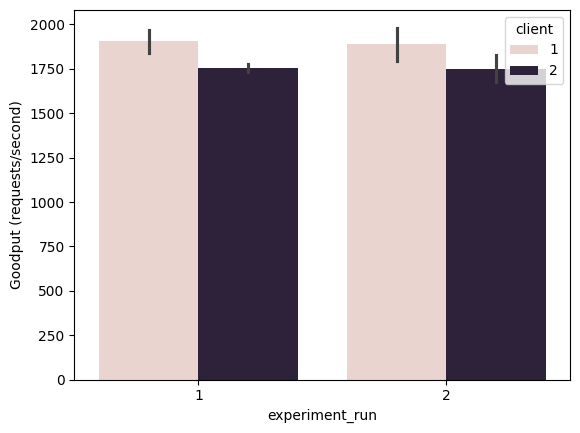

In [33]:
import seaborn as sns

sns.barplot(data=df_performance, x='experiment_run', y='Goodput (requests/second)', hue='client')
plt.show()


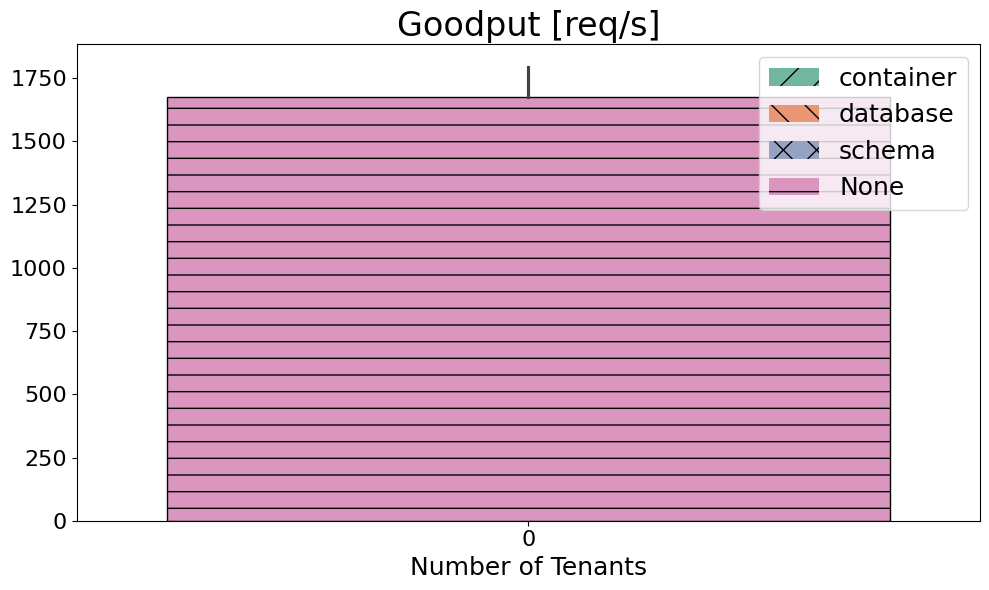

In [34]:
plot_bars(df_performance, y='Goodput (requests/second)', title='Goodput [req/s]', estimator='min', b_plot_save=b_plot_save, filename_prefix=filename_prefix)

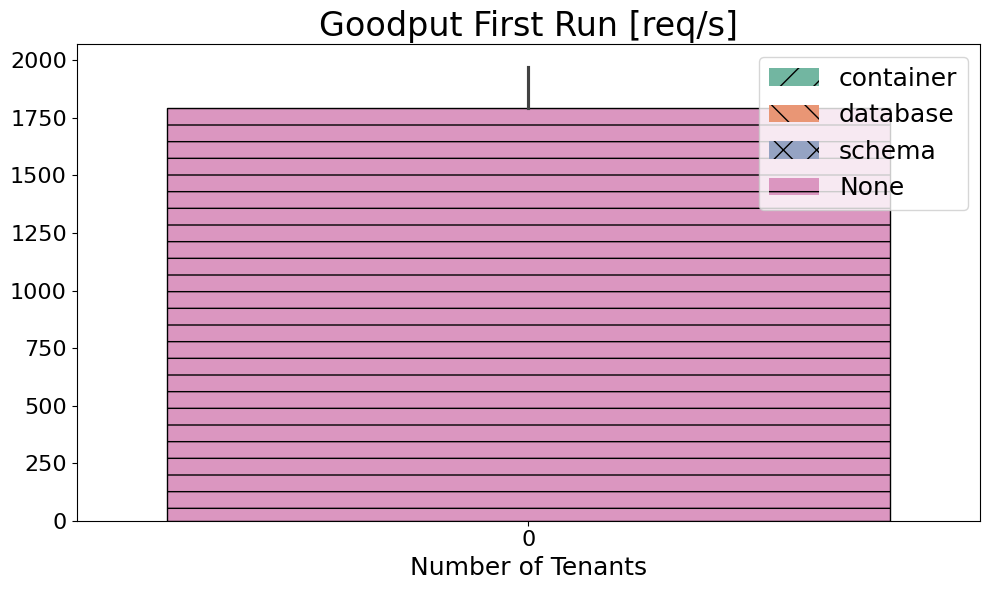

In [35]:
plot_bars(df_performance_first, y='Goodput (requests/second)', title='Goodput First Run [req/s]', estimator='min', b_plot_save=b_plot_save, filename_prefix=filename_prefix)

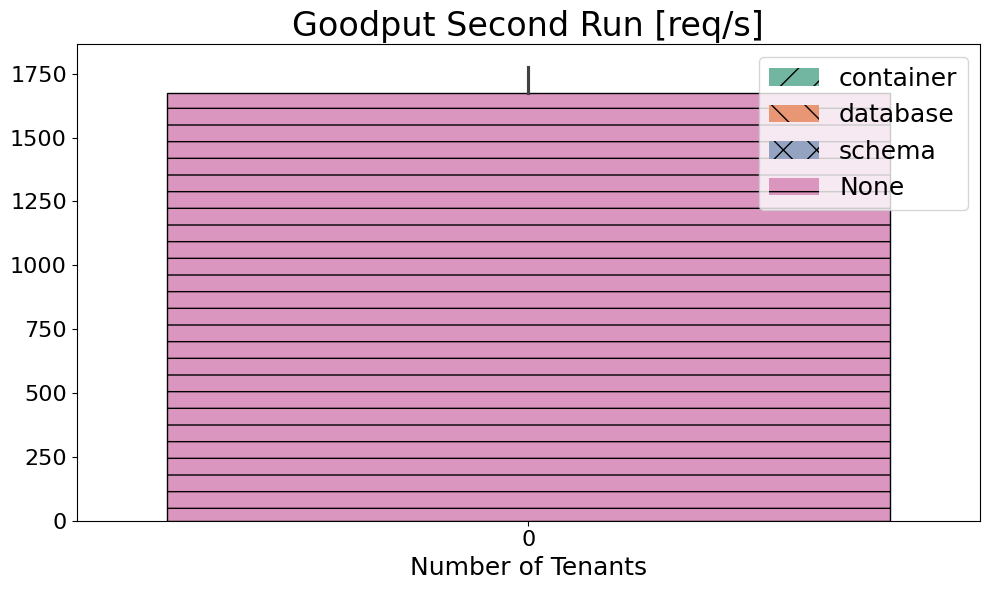

In [36]:
plot_bars(df_performance_second, y='Goodput (requests/second)', title='Goodput Second Run [req/s]', estimator='min', b_plot_save=b_plot_save, filename_prefix=filename_prefix)

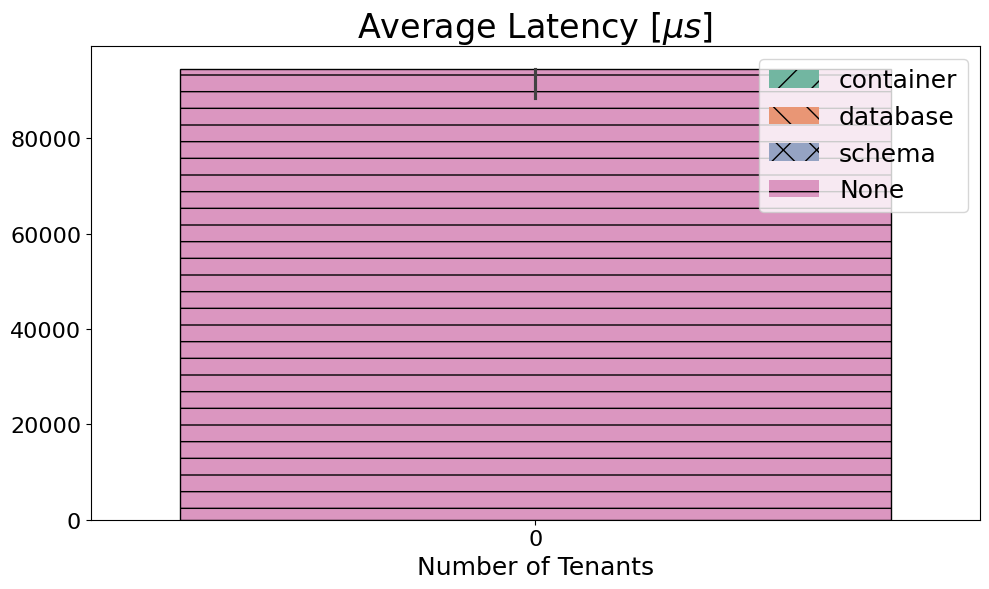

In [37]:
plot_bars(df_performance, y='Latency Distribution.Average Latency (microseconds)', title=r'Average Latency [$\mu s$]', estimator='max', b_plot_save=b_plot_save, filename_prefix=filename_prefix)

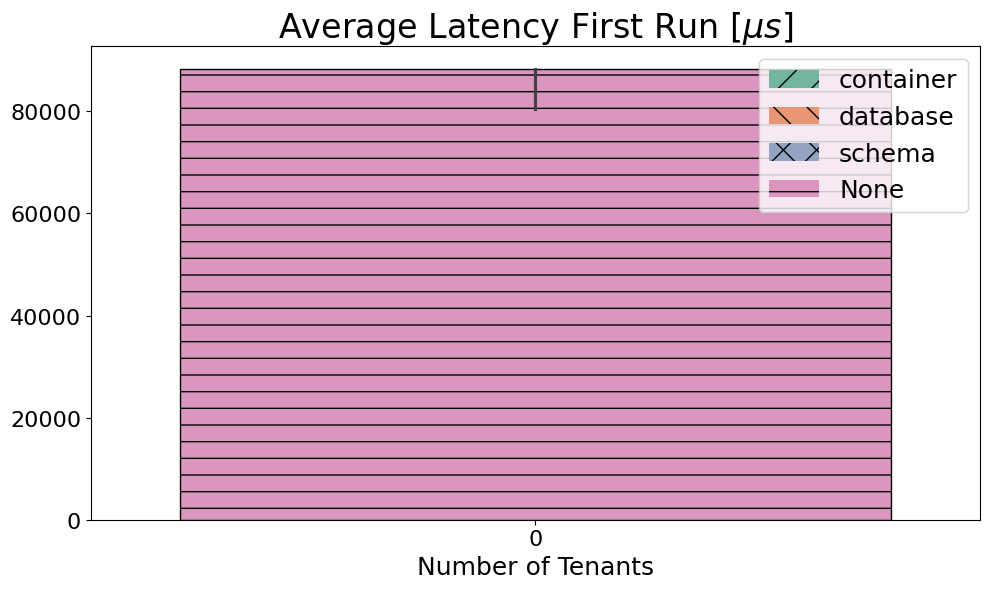

In [38]:
plot_bars(df_performance_first, y='Latency Distribution.Average Latency (microseconds)', title=r'Average Latency First Run [$\mu s$]', estimator='max', b_plot_save=b_plot_save, filename_prefix=filename_prefix)

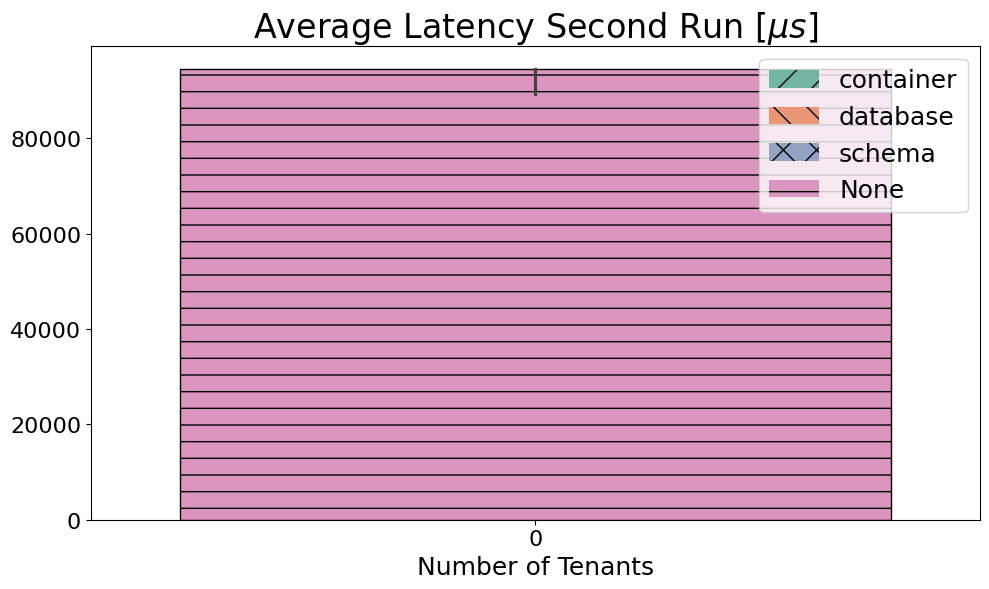

In [39]:
plot_bars(df_performance_second, y='Latency Distribution.Average Latency (microseconds)', title=r'Average Latency Second Run [$\mu s$]', estimator='max', b_plot_save=b_plot_save, filename_prefix=filename_prefix)

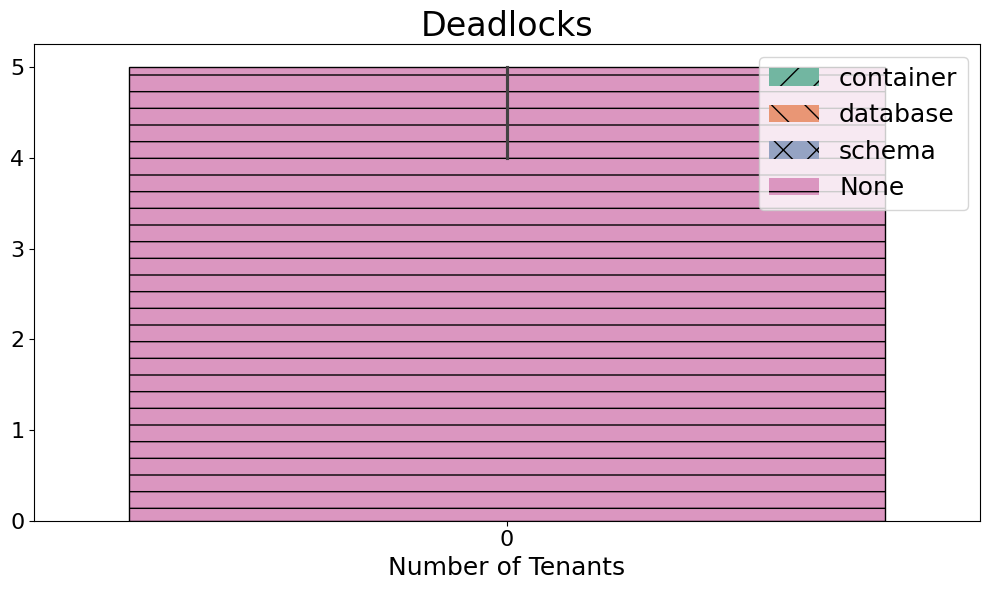

In [40]:
plot_bars(df_performance, y='num_errors', title='Deadlocks', estimator='max', b_plot_save=b_plot_save, filename_prefix=filename_prefix)

In [41]:
df_performance = collect.get_loading_time_max_all()

df_performance_first = df_performance[df_performance['client']==1]
df_performance_second = df_performance[df_performance['client']==2]

df_performance

,time_load,time_ingest,time_check,terminals,pods,tenant,client,datadisk,type,num_tenants,vol_tenants,code
PostgreSQL-1-1-1024-1-1,601.0,245.0,355.0,1,1,,1,0,None,0,False,1775852722
PostgreSQL-1-1-1024-1-2,601.0,245.0,355.0,1,2,,2,0,None,0,False,1775852722
PostgreSQL-1-1-1024-2-1,665.0,273.0,391.0,1,1,,1,0,None,0,False,1775852722
PostgreSQL-1-1-1024-2-2,665.0,273.0,391.0,1,2,,2,0,None,0,False,1775852722
PostgreSQL-1-1-1024-1-1,608.0,253.0,354.0,1,4,,1,0,None,0,False,1775855486
PostgreSQL-1-1-1024-1-2,608.0,253.0,354.0,1,8,,2,0,None,0,False,1775855486
PostgreSQL-1-1-1024-2-1,668.0,276.0,391.0,1,4,,1,0,None,0,False,1775855486
PostgreSQL-1-1-1024-2-2,668.0,276.0,391.0,1,8,,2,0,None,0,False,1775855486


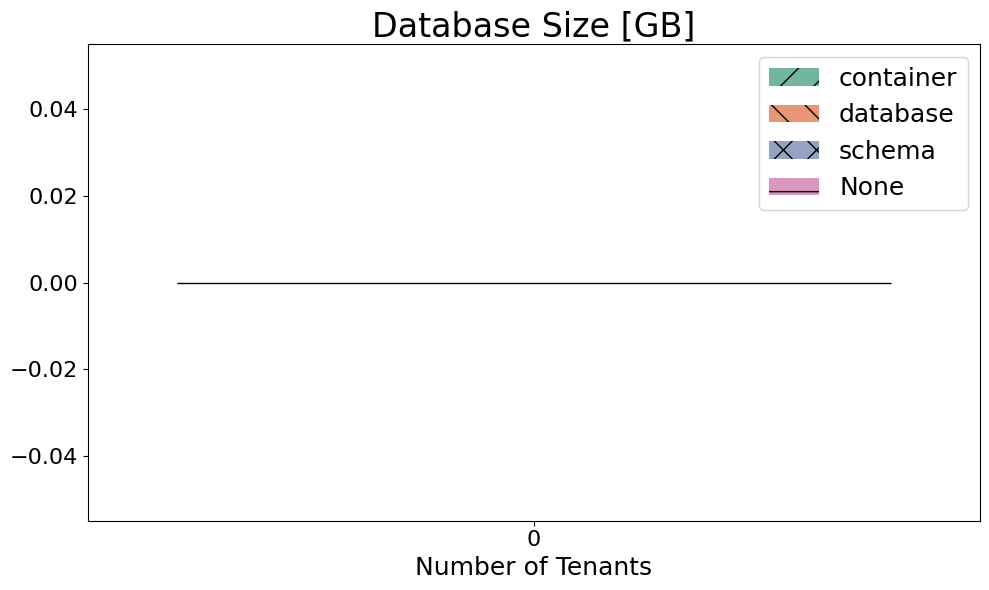

In [42]:
df_performance_first = df_performance[df_performance['client'] == 1]
# Divide datadisk by the count of rows with the same type and num_tenants
df = df_performance_first.copy()
# Create a mask for rows where type is not "container"
mask = df['type'] != 'container'

# Only apply the group count to the relevant rows
group_counts = df[mask].groupby(['type', 'num_tenants'])['datadisk'].transform('count')

# Initialize the column with NaN (or 0, if preferred)
df['datadisk_normalized'] = df['datadisk'] / 1024

# Apply the normalized value only where the mask is True
df.loc[mask, 'datadisk_normalized'] = df.loc[mask, 'datadisk'] / group_counts / 1024

plot_bars(df, y='datadisk_normalized', title='Database Size [GB]', estimator='sum', b_plot_save=b_plot_save, filename_prefix=filename_prefix)

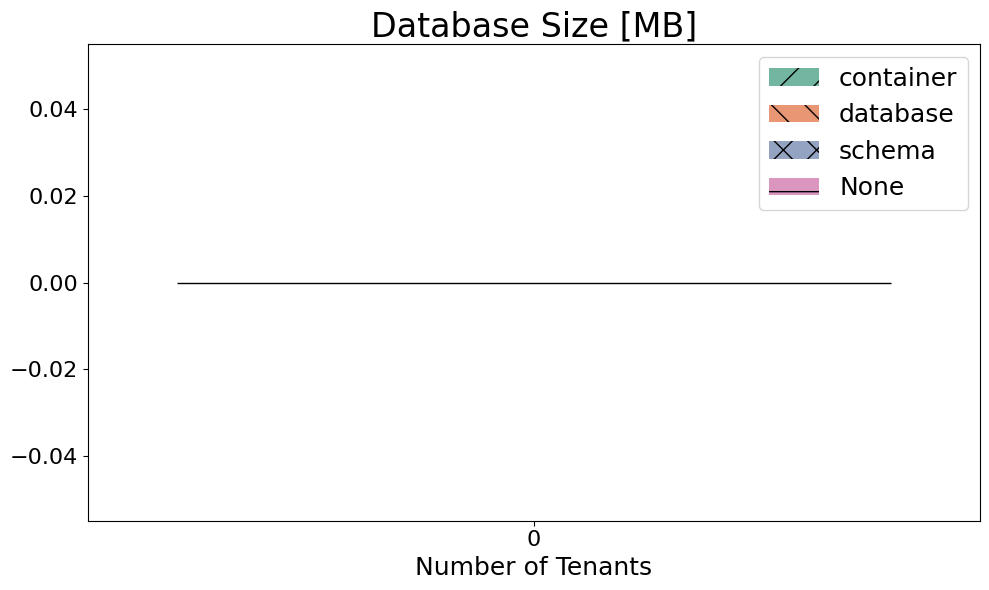

In [43]:
plot_bars(df_performance_first, y='datadisk', title='Database Size [MB]', estimator='sum', b_plot_save=b_plot_save, filename_prefix=filename_prefix)

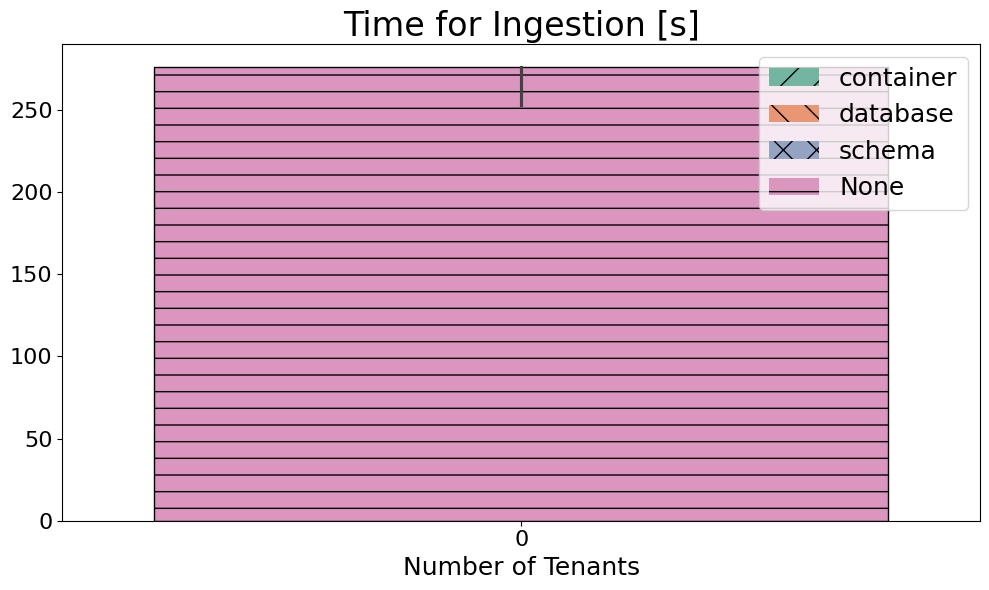

In [44]:
plot_bars(df_performance_first, y='time_ingest', title='Time for Ingestion [s]', estimator='max', b_plot_save=b_plot_save, filename_prefix=filename_prefix)

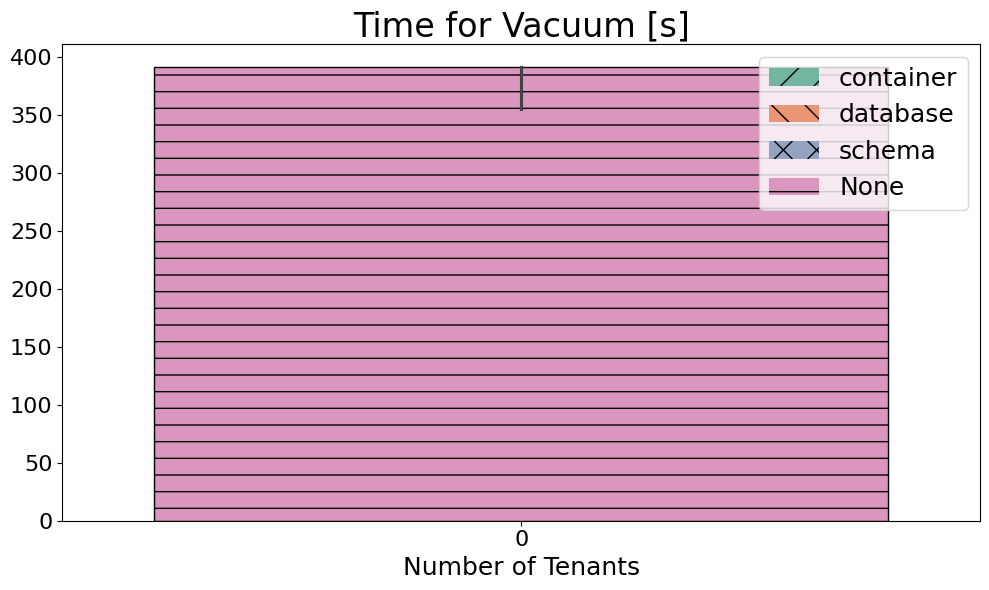

In [45]:
plot_bars(df_performance_first, y='time_check', title='Time for Vacuum [s]', estimator='max', b_plot_save=b_plot_save, filename_prefix=filename_prefix)

# Hardware Monitoring for Benchmarking Phase

In [46]:
df_performance = collect.get_monitoring_all(type="stream")

df_performance_first = df_performance[df_performance['client']==1]
df_performance_second = df_performance[df_performance['client']==2]

df_performance.T

,0,1,2,3,0,1,2,3
experiment_run,1,1,2,2,1,1,2,2
client,1,2,1,2,1,2,1,2
Memory Usage [MiB],9193.61,9872.4,9075.06,9869.83,9213.55,9939.76,9192.23,9874.04
Memory Usage Cached [MiB],11156.84,12384.32,11033.07,12401.17,11169.15,12492.83,11155.62,12415.73
CPU Utilization,7.25,7.13,7.38,6.89,6.95,6.78,6.71,6.59
CPU Throttle,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CPU Throttled Time [s],0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CPU Utilization Time [s],2578.09,2557.14,2639.5,2320.33,2119.83,2088.34,2148.79,2187.36
CPU User Time [s],1472.71,1456.08,1538.29,1347.28,1215.12,1194.67,1216.51,1243.81
CPU System Time [s],1105.38,1101.06,1101.21,973.06,904.71,893.67,932.27,943.54


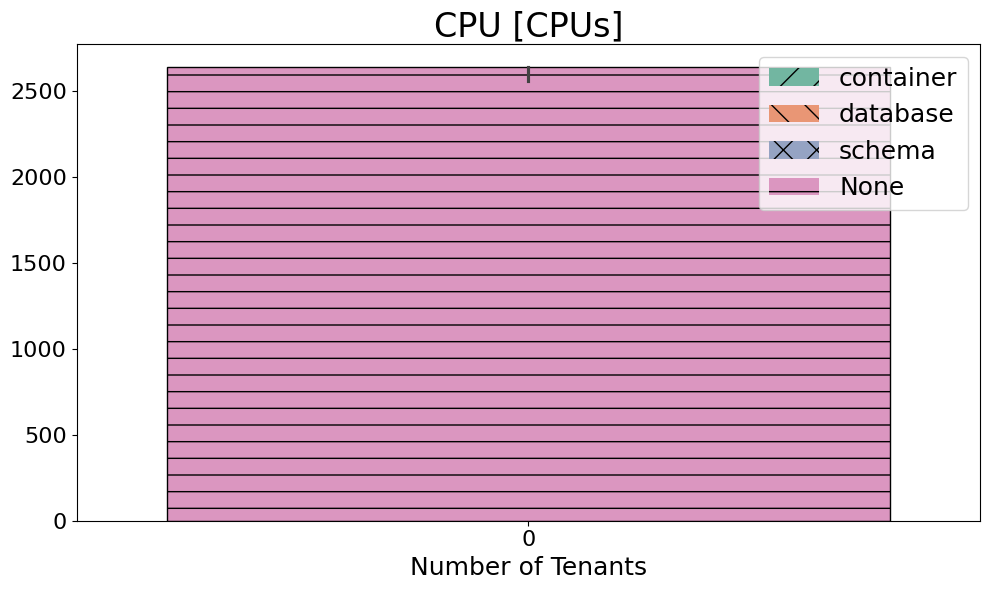

In [47]:
plot_bars(df_performance, y='CPU Utilization Time [s]', title='CPU [CPUs]', estimator='max', b_plot_save=b_plot_save, filename_prefix=filename_prefix)

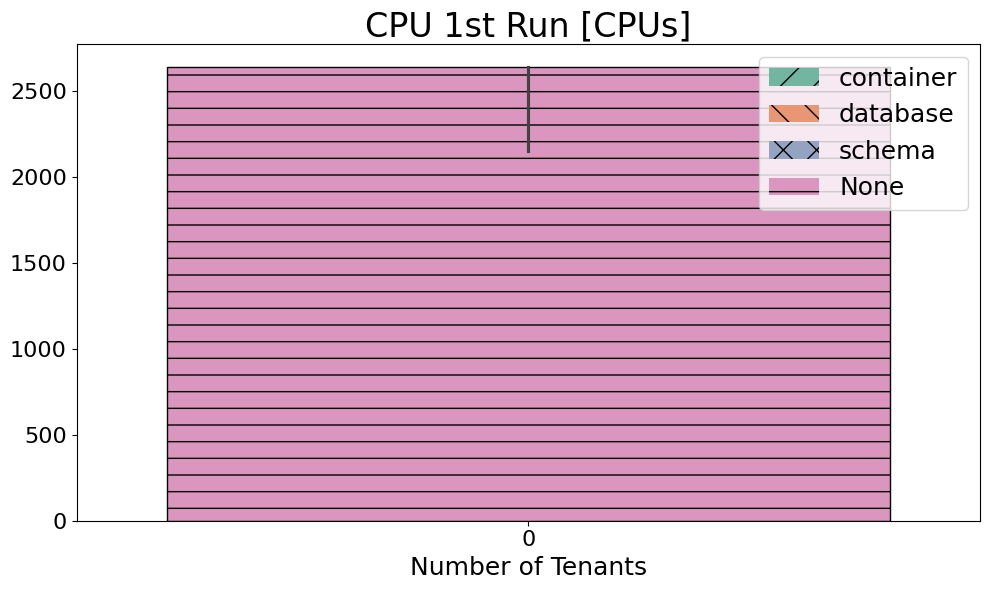

In [48]:
plot_bars(df_performance_first, y='CPU Utilization Time [s]', title='CPU 1st Run [CPUs]', estimator='max', b_plot_save=b_plot_save, filename_prefix=filename_prefix)

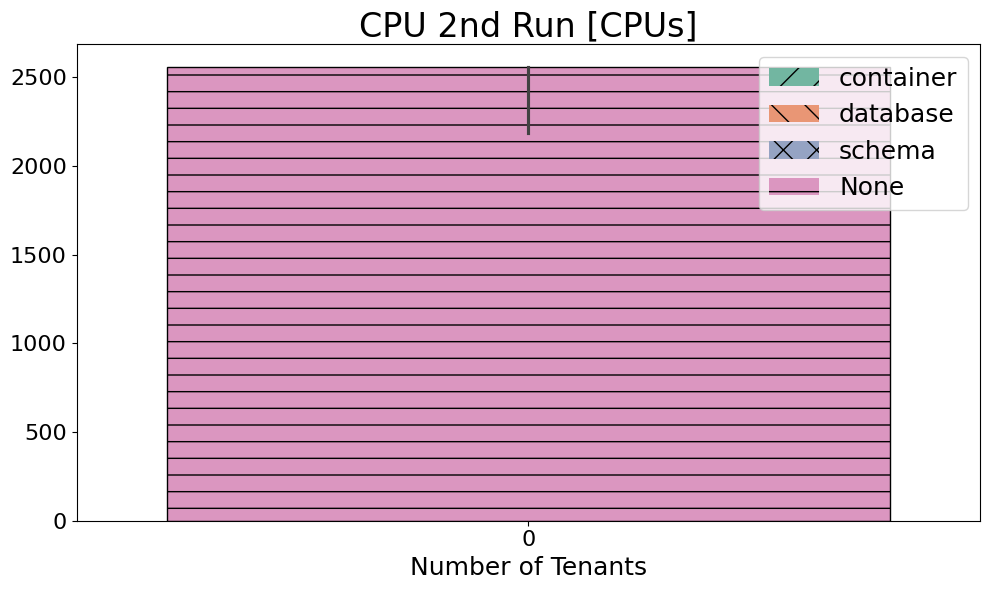

In [49]:
plot_bars(df_performance_second, y='CPU Utilization Time [s]', title='CPU 2nd Run [CPUs]', estimator='max', b_plot_save=b_plot_save, filename_prefix=filename_prefix)

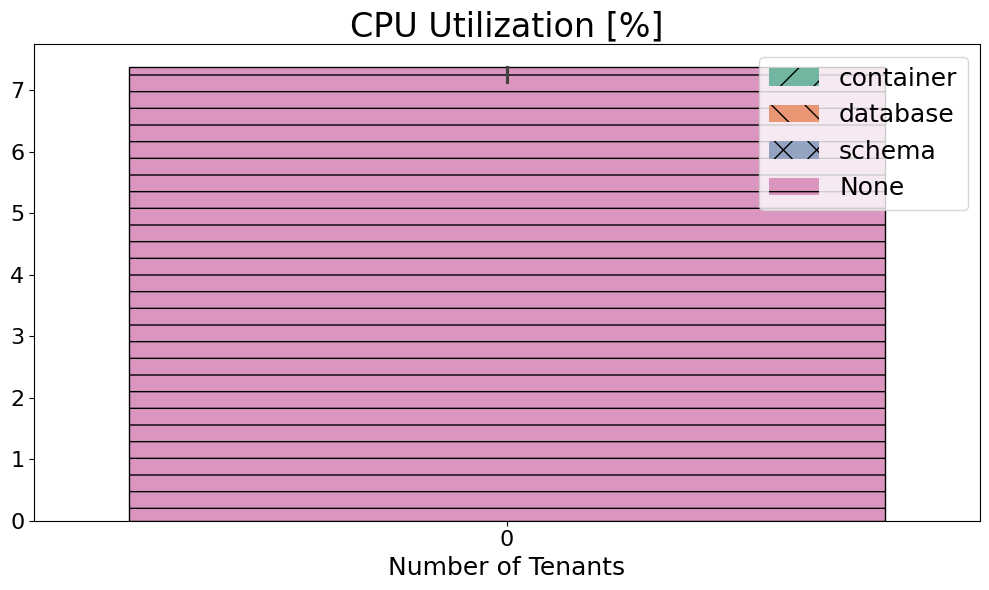

In [50]:
plot_bars(df_performance, y='CPU Utilization', title='CPU Utilization [%]', estimator='max', b_plot_save=b_plot_save, filename_prefix=filename_prefix)

## Custom Aggregation

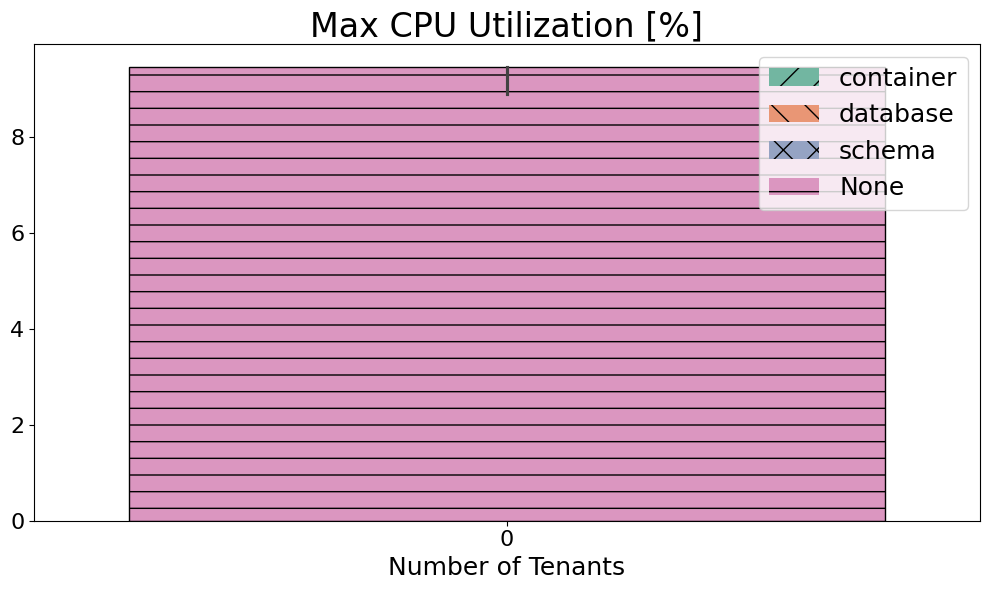

In [51]:
metric = 'total_cpu_util'

df_performance_series = collect.get_monitoring_timeseries_all(metric)

df_agg = (
    df_performance_series.groupby(["client", "type", "num_tenants"])["value"]
      .max()
      .reset_index()
)
plot_bars(df_agg, y='value', title='Max CPU Utilization [%]', estimator='max', b_plot_save=b_plot_save, filename_prefix=filename_prefix)
#df_agg

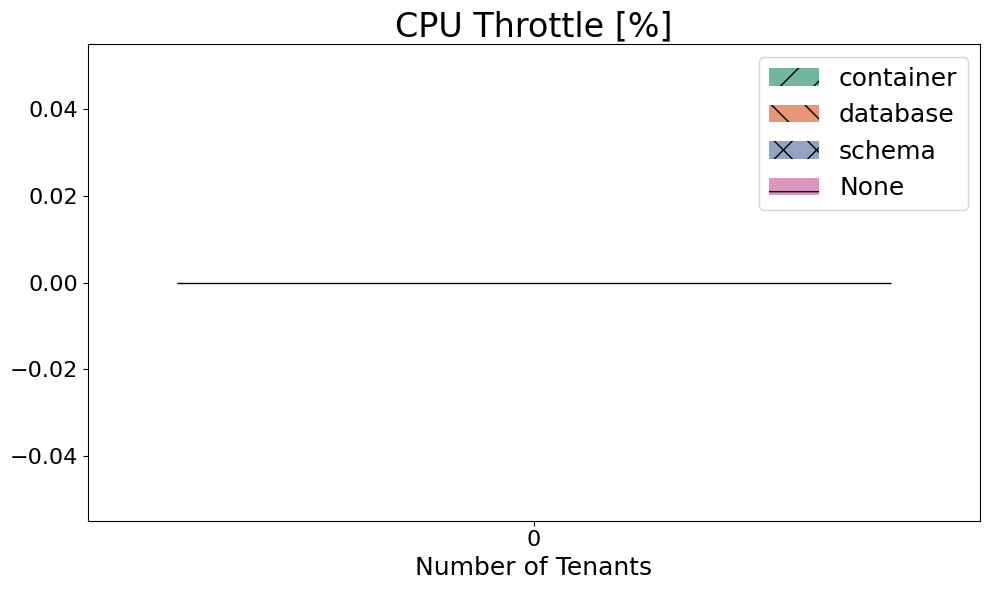

In [52]:
plot_bars(df_performance, y='CPU Throttle', title='CPU Throttle [%]', estimator='max', b_plot_save=b_plot_save, filename_prefix=filename_prefix)

## Custom Aggregation and Scale

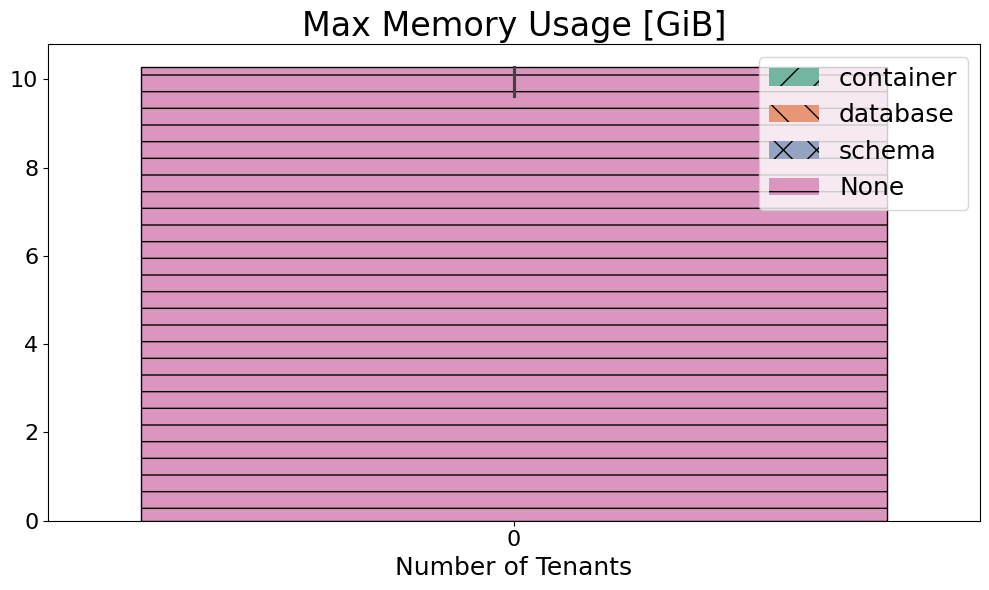

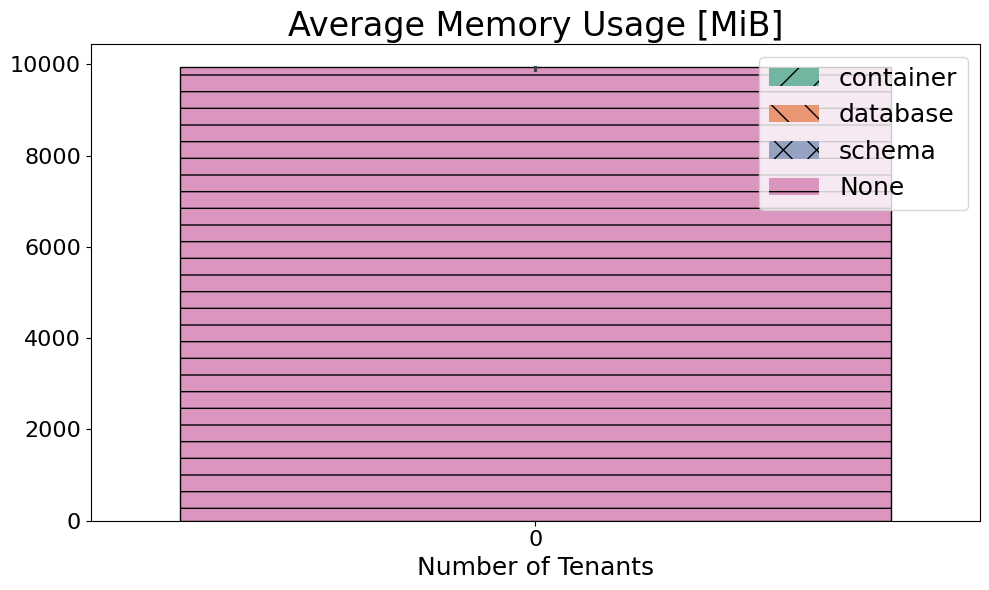

In [53]:
metric = 'total_cpu_memory'

df_performance_series = collect.get_monitoring_timeseries_all(metric)

df_agg = (
    df_performance_series.groupby(["client", "type", "num_tenants"])["value"]
      .max()
      .reset_index()
)
df_agg['value'] = df_agg['value'] / 1024.
plot_bars(df_agg, y='value', title='Max Memory Usage [GiB]', estimator='max', b_plot_save=b_plot_save, filename_prefix=filename_prefix)

plot_bars(df_performance, y='Memory Usage [MiB]', title='Average Memory Usage [MiB]', estimator='max', b_plot_save=b_plot_save, filename_prefix=filename_prefix)

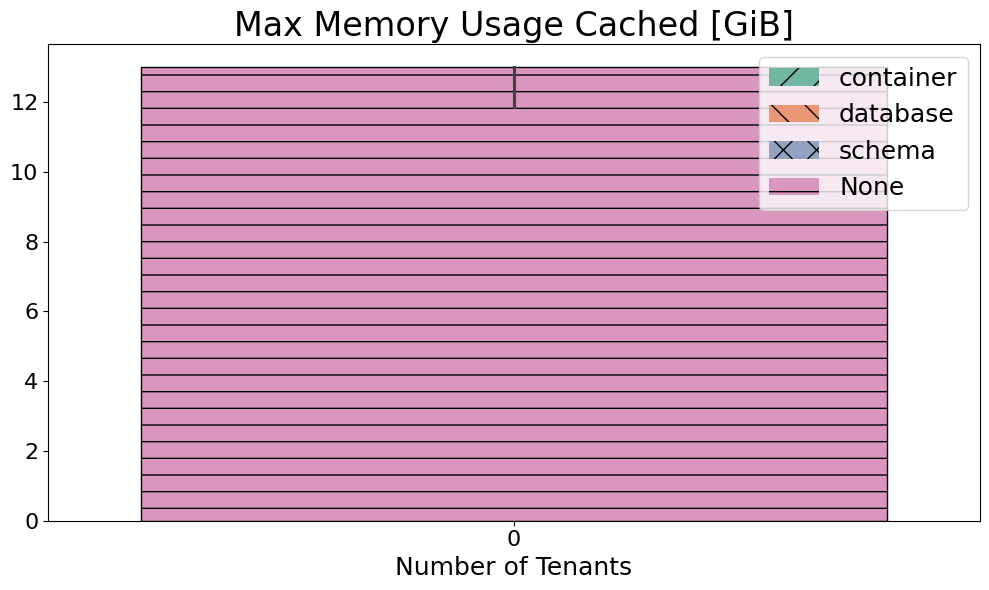

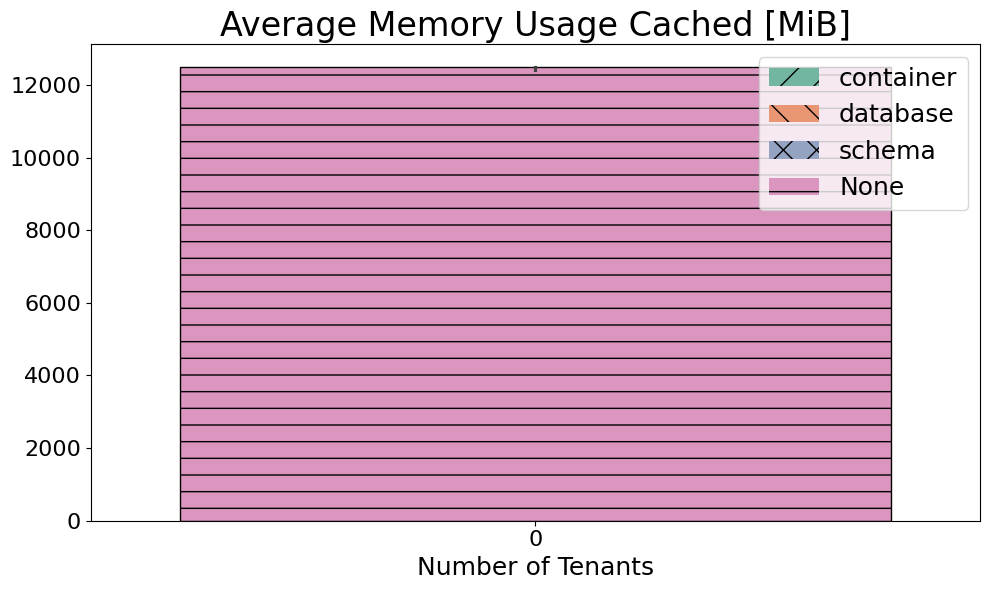

In [54]:
metric = 'total_cpu_memory_cached'

df_performance_series = collect.get_monitoring_timeseries_all(metric)

df_agg = (
    df_performance_series.groupby(["client", "type", "num_tenants"])["value"]
      .max()
      .reset_index()
)
df_agg['value'] = df_agg['value'] / 1024.
plot_bars(df_agg, y='value', title='Max Memory Usage Cached [GiB]', estimator='max', b_plot_save=b_plot_save, filename_prefix=filename_prefix)

plot_bars(df_performance, y='Memory Usage Cached [MiB]', title='Average Memory Usage Cached [MiB]', estimator='max', b_plot_save=b_plot_save, filename_prefix=filename_prefix)

# Hardware Monitoring for Loading Phase

In [55]:
df_performance = collect.get_monitoring_all("loading")

df_performance_first = df_performance[df_performance['client']==1]
df_performance_second = df_performance[df_performance['client']==2]

df_performance_first

,experiment_run,client,Memory Usage [MiB],Memory Usage Cached [MiB],CPU Utilization,CPU Throttle,CPU Throttled Time [s],CPU Utilization Time [s],CPU User Time [s],CPU System Time [s],...,Dead tuples per vacuum operation [tuples/vacuum],Number of WAL Segments,Total WAL Size [GiB],WAL Segments Growth Rate [segments/s],WAL Growth Rate [MiB/s],Average WAL Segment Size [MiB],type,num_tenants,vol_tenants,code
0,1,1,6893.96,7812.44,2.20,0.0,0.0,743.49,675.68,67.81,...,0.0,95.50,1.49,0.32,5.13,16.0,None,0,False,1775852722
2,2,1,7349.80,8704.14,1.65,0.0,0.0,6150.58,3754.07,2396.51,...,0.0,98.10,1.53,0.32,5.11,16.0,None,0,False,1775852722
0,1,1,6909.47,7821.62,1.78,0.0,0.0,677.26,611.10,66.16,...,0.0,94.57,1.48,0.32,5.08,16.0,None,0,False,1775855486
2,2,1,7206.97,8420.17,1.63,0.0,0.0,5871.49,3565.82,2305.66,...,0.0,96.70,1.51,0.31,5.03,16.0,None,0,False,1775855486


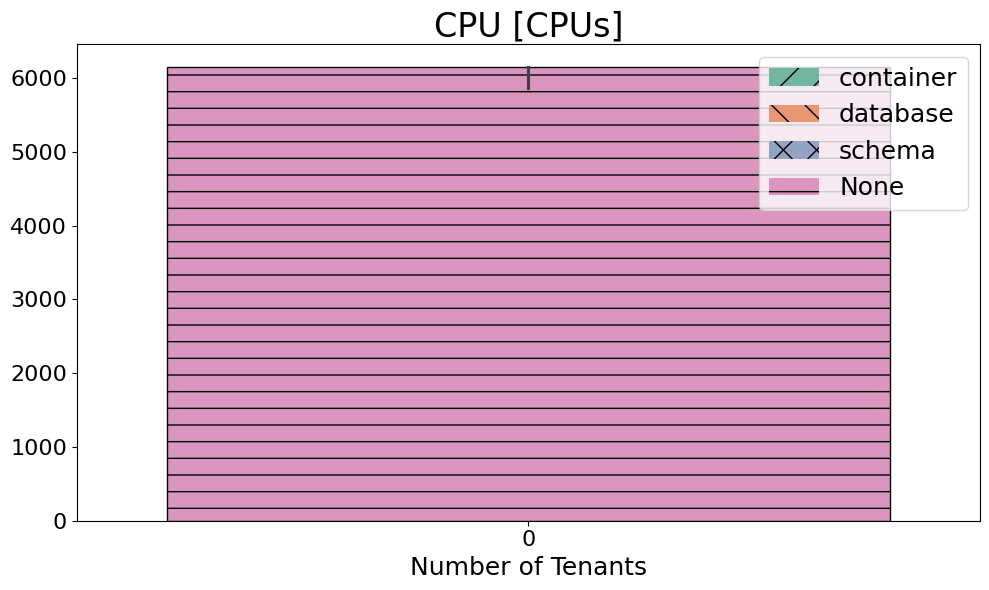

In [56]:
plot_bars(df_performance, y='CPU Utilization Time [s]', title='CPU [CPUs]', estimator='max', b_plot_save=b_plot_save, filename_prefix=filename_prefix)

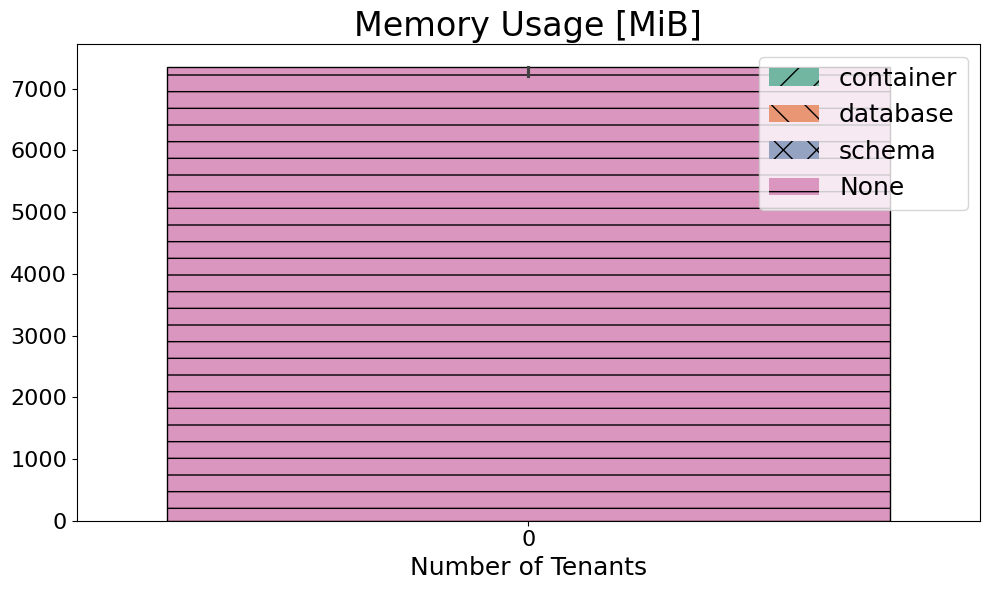

In [57]:
plot_bars(df_performance, y='Memory Usage [MiB]', title='Memory Usage [MiB]', estimator='max', b_plot_save=b_plot_save, filename_prefix=filename_prefix)

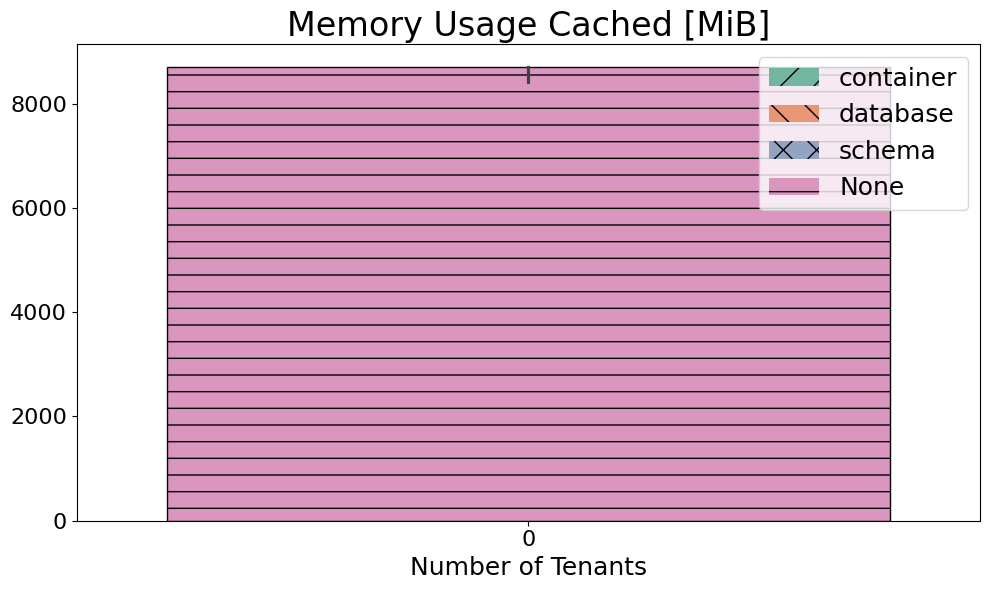

In [58]:
plot_bars(df_performance, y='Memory Usage Cached [MiB]', title='Memory Usage Cached [MiB]', estimator='max', b_plot_save=b_plot_save, filename_prefix=filename_prefix)

# Efficiency

In [59]:
client = 1

df_performance_monitoring = collect.get_monitoring_all(type="stream")
df_performance_monitoring = df_performance_monitoring[df_performance_monitoring['client'] == client]
df_performance = collect.get_performance_all()
df_performance = df_performance[df_performance['client'] == client]
merged_df = pd.merge(df_performance, df_performance_monitoring, on=['type', 'num_tenants', 'code', 'client'], how='inner')
#merged_df['I_Lat'] = 1./merged_df['E_Lat']
merged_df['E_Tpx'] = merged_df['Goodput (requests/second)'] / merged_df['CPU Utilization Time [s]'] * 600.
merged_df['E_Lat'] = 1./np.sqrt(merged_df['Latency Distribution.Average Latency (microseconds)']*merged_df['CPU Utilization Time [s]']/1E6)
merged_df['E_RAM'] = (merged_df['Goodput (requests/second)']) / merged_df['Memory Usage [MiB]']
merged_df

,connection,configuration,experiment_run_x,client,code,pod,pod_count,duration,bench,profile,...,Dead tuples per vacuum operation [tuples/vacuum],Number of WAL Segments,Total WAL Size [GiB],WAL Segments Growth Rate [segments/s],WAL Growth Rate [MiB/s],Average WAL Segment Size [MiB],vol_tenants_y,E_Tpx,E_Lat,E_RAM
0,PostgreSQL-1-1-1024-1-1,PostgreSQL-1-1-1024,1,1,1775852722,kljq4.dbmsbenchmarker,1,307,tpcc,postgres,...,inf,166.70,2.60,0.10,1.63,16.0,False,458.723275,0.069435,0.214393
1,PostgreSQL-1-1-1024-1-1,PostgreSQL-1-1-1024,1,1,1775852722,kljq4.dbmsbenchmarker,1,307,tpcc,postgres,...,inf,166.60,2.60,0.08,1.30,16.0,False,448.050725,0.068622,0.217194
2,PostgreSQL-1-1-1024-2-1,PostgreSQL-1-1-1024,2,1,1775852722,dfwqk.dbmsbenchmarker,1,305,tpcc,postgres,...,inf,166.70,2.60,0.10,1.63,16.0,False,461.361696,0.069629,0.215627
3,PostgreSQL-1-1-1024-2-1,PostgreSQL-1-1-1024,2,1,1775852722,dfwqk.dbmsbenchmarker,1,305,tpcc,postgres,...,inf,166.60,2.60,0.08,1.30,16.0,False,450.627761,0.068814,0.218443
4,PostgreSQL-1-1-1024-1-1,PostgreSQL-1-1-1024,1,1,1775855486,cvnpd.dbmsbenchmarkerh6qss.dbmsbenchmarkerschkb.dbmsbenchmarkerz28zb.dbmsbenchmarker,4,305,tpcc,postgres,...,inf,166.29,2.60,0.11,1.70,16.0,False,520.296316,0.073941,0.199514
5,PostgreSQL-1-1-1024-1-1,PostgreSQL-1-1-1024,1,1,1775855486,cvnpd.dbmsbenchmarkerh6qss.dbmsbenchmarkerschkb.dbmsbenchmarkerz28zb.dbmsbenchmarker,4,305,tpcc,postgres,...,inf,166.02,2.59,0.08,1.34,16.0,False,513.284099,0.073441,0.199977
6,PostgreSQL-1-1-1024-2-1,PostgreSQL-1-1-1024,2,1,1775855486,8hb8h.dbmsbenchmarker9s2tg.dbmsbenchmarkerqhcl8.dbmsbenchmarkert242d.dbmsbenchmarker,4,305,tpcc,postgres,...,inf,166.29,2.60,0.11,1.70,16.0,False,507.933021,0.073058,0.194773
7,PostgreSQL-1-1-1024-2-1,PostgreSQL-1-1-1024,2,1,1775855486,8hb8h.dbmsbenchmarker9s2tg.dbmsbenchmarkerqhcl8.dbmsbenchmarkert242d.dbmsbenchmarker,4,305,tpcc,postgres,...,inf,166.02,2.59,0.08,1.34,16.0,False,501.087429,0.072564,0.195225


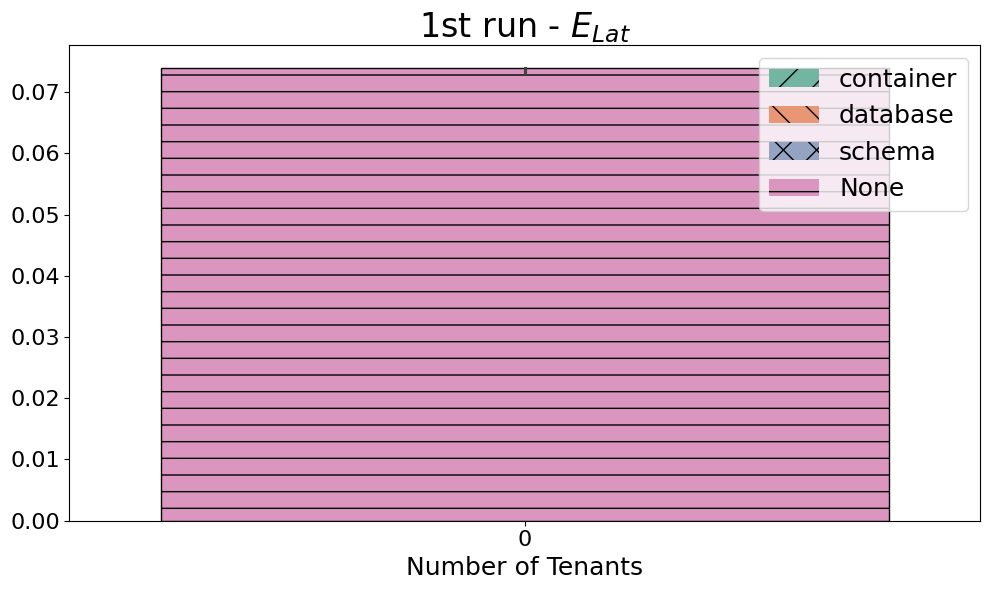

In [60]:
plot_bars(merged_df, y='E_Lat', title='1st run - $E_{Lat}$', estimator='max', b_plot_save=b_plot_save, filename_prefix=filename_prefix)

In [61]:
#plot_bars(merged_df, y='I_Lat', title='1st run - $I_{Lat}$', estimator='max', b_plot_save=b_plot_save, filename_prefix=filename_prefix)

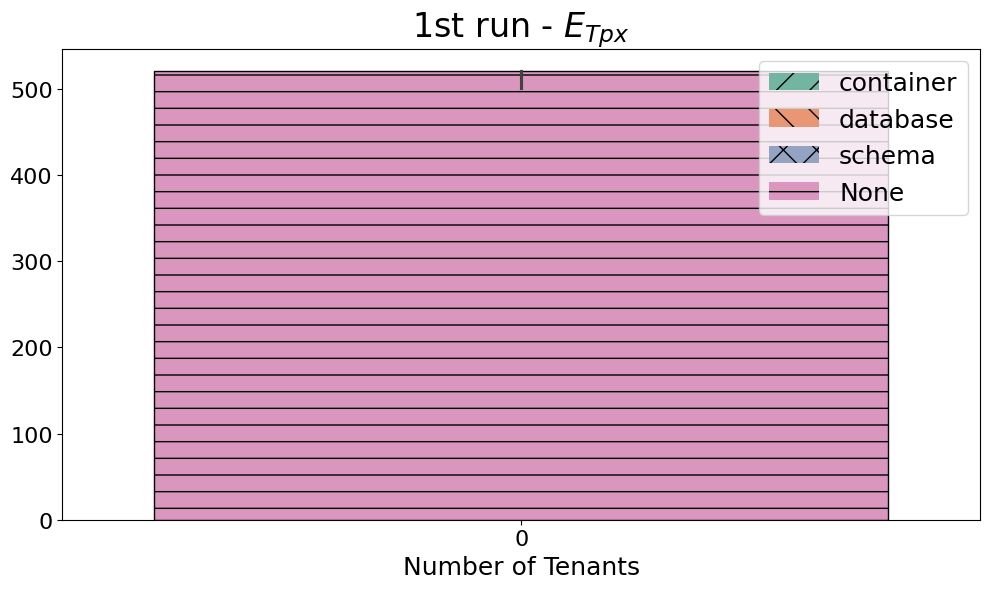

In [62]:
plot_bars(merged_df, y='E_Tpx', title='1st run - $E_{Tpx}$', estimator='max', b_plot_save=b_plot_save, filename_prefix=filename_prefix)

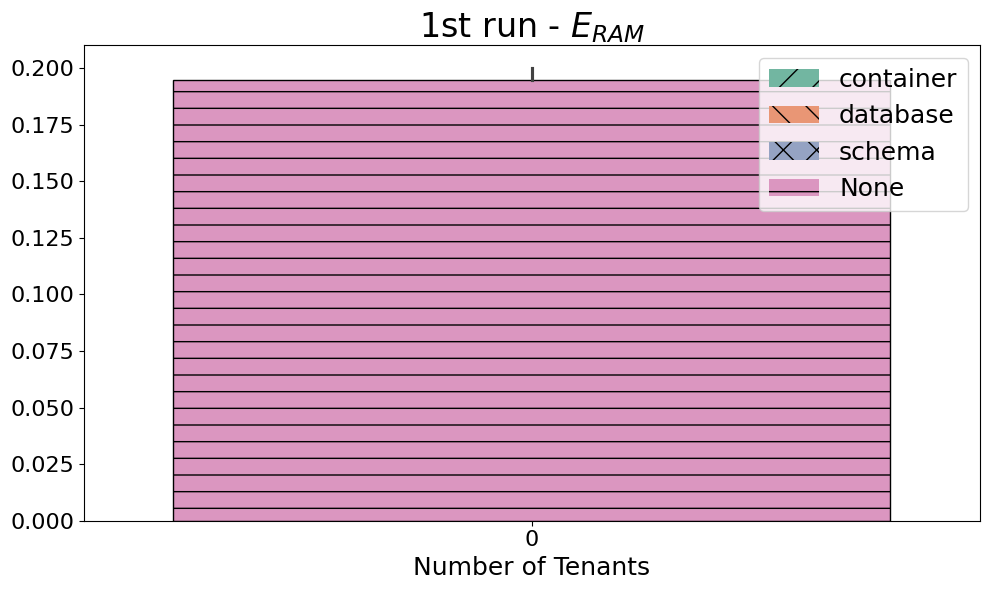

In [63]:
plot_bars(merged_df, y='E_RAM', title='1st run - $E_{RAM}$', estimator='min', b_plot_save=b_plot_save, filename_prefix=filename_prefix)

In [64]:
client = 2

df_performance_monitoring = collect.get_monitoring_all(type="stream")
df_performance_monitoring = df_performance_monitoring[df_performance_monitoring['client'] == client]
df_performance = collect.get_performance_all()
df_performance = df_performance[df_performance['client'] == client]
merged_df = pd.merge(df_performance, df_performance_monitoring, on=['type', 'num_tenants', 'code', 'client'], how='inner')
#merged_df['CPUs/Request'] = merged_df['CPU [CPUs]'] / merged_df['Goodput (requests/second)'] / 600.
merged_df['E_Tpx'] = merged_df['Goodput (requests/second)'] / merged_df['CPU Utilization Time [s]'] * 600.
merged_df['E_Lat'] = 1./np.sqrt(merged_df['Latency Distribution.Average Latency (microseconds)']*merged_df['CPU Utilization Time [s]']/1E6)
merged_df['E_RAM'] = (merged_df['Goodput (requests/second)']) / merged_df['Memory Usage [MiB]']

merged_df

,connection,configuration,experiment_run_x,client,code,pod,pod_count,duration,bench,profile,...,Dead tuples per vacuum operation [tuples/vacuum],Number of WAL Segments,Total WAL Size [GiB],WAL Segments Growth Rate [segments/s],WAL Growth Rate [MiB/s],Average WAL Segment Size [MiB],vol_tenants_y,E_Tpx,E_Lat,E_RAM
0,PostgreSQL-1-1-1024-1-2,PostgreSQL-1-1-1024,1,2,1775852722,m8gls.dbmsbenchmarkernvpdg.dbmsbenchmarker,2,304,tpcc,postgres,...,inf,229.02,3.58,0.19,3.10,16.0,False,416.705313,0.066172,0.179891
1,PostgreSQL-1-1-1024-1-2,PostgreSQL-1-1-1024,1,2,1775852722,m8gls.dbmsbenchmarkernvpdg.dbmsbenchmarker,2,304,tpcc,postgres,...,inf,231.80,3.62,0.20,3.25,16.0,False,459.233740,0.069467,0.179938
2,PostgreSQL-1-1-1024-2-2,PostgreSQL-1-1-1024,2,2,1775852722,6j9x2.dbmsbenchmarker8pv6v.dbmsbenchmarker,2,304,tpcc,postgres,...,inf,229.02,3.58,0.19,3.10,16.0,False,428.859467,0.067138,0.185138
3,PostgreSQL-1-1-1024-2-2,PostgreSQL-1-1-1024,2,2,1775852722,6j9x2.dbmsbenchmarker8pv6v.dbmsbenchmarker,2,304,tpcc,postgres,...,inf,231.80,3.62,0.20,3.25,16.0,False,472.628331,0.070480,0.185186
4,PostgreSQL-1-1-1024-1-2,PostgreSQL-1-1-1024,1,2,1775855486,2ns27.dbmsbenchmarker7659t.dbmsbenchmarkerbwjj8.dbmsbenchmarkerht6xw.dbmsbenchmarkers8q4v.dbmsbenchmarkervj4hq.dbmsbenchmarkerxgj6b.dbmsbenchmarkerxk2q7.dbmsbenchmarker,8,308,tpcc,postgres,...,inf,231.28,3.61,0.20,3.20,16.0,False,496.929449,0.072305,0.174008
5,PostgreSQL-1-1-1024-1-2,PostgreSQL-1-1-1024,1,2,1775855486,2ns27.dbmsbenchmarker7659t.dbmsbenchmarkerbwjj8.dbmsbenchmarkerht6xw.dbmsbenchmarkers8q4v.dbmsbenchmarkervj4hq.dbmsbenchmarkerxgj6b.dbmsbenchmarkerxk2q7.dbmsbenchmarker,8,308,tpcc,postgres,...,inf,228.43,3.57,0.19,3.10,16.0,False,474.433859,0.070650,0.175166
6,PostgreSQL-1-1-1024-2-2,PostgreSQL-1-1-1024,2,2,1775855486,9mnjp.dbmsbenchmarkerc6l7n.dbmsbenchmarkerg6288.dbmsbenchmarkermklcl.dbmsbenchmarkernsh6m.dbmsbenchmarkerphbzp.dbmsbenchmarkerr5lpc.dbmsbenchmarkerxgnsx.dbmsbenchmarker,8,307,tpcc,postgres,...,inf,231.28,3.61,0.20,3.20,16.0,False,481.038200,0.071147,0.168443
7,PostgreSQL-1-1-1024-2-2,PostgreSQL-1-1-1024,2,2,1775855486,9mnjp.dbmsbenchmarkerc6l7n.dbmsbenchmarkerg6288.dbmsbenchmarkermklcl.dbmsbenchmarkernsh6m.dbmsbenchmarkerphbzp.dbmsbenchmarkerr5lpc.dbmsbenchmarkerxgnsx.dbmsbenchmarker,8,307,tpcc,postgres,...,inf,228.43,3.57,0.19,3.10,16.0,False,459.261994,0.069518,0.169564


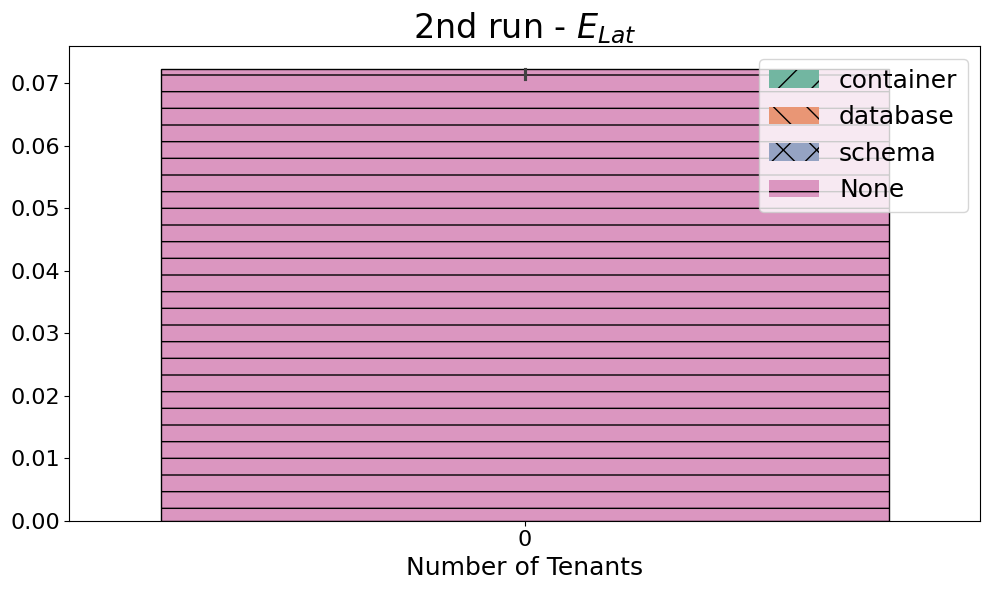

In [65]:
plot_bars(merged_df, y='E_Lat', title='2nd run - $E_{Lat}$', estimator='max', b_plot_save=b_plot_save, filename_prefix=filename_prefix)

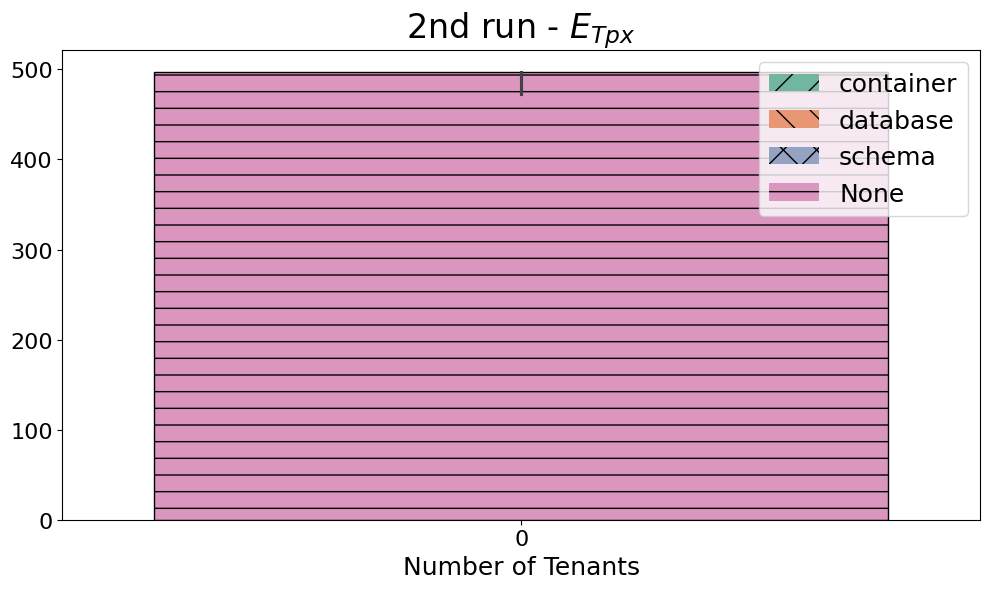

In [66]:
plot_bars(merged_df, y='E_Tpx', title='2nd run - $E_{Tpx}$', estimator='max', b_plot_save=b_plot_save, filename_prefix=filename_prefix)

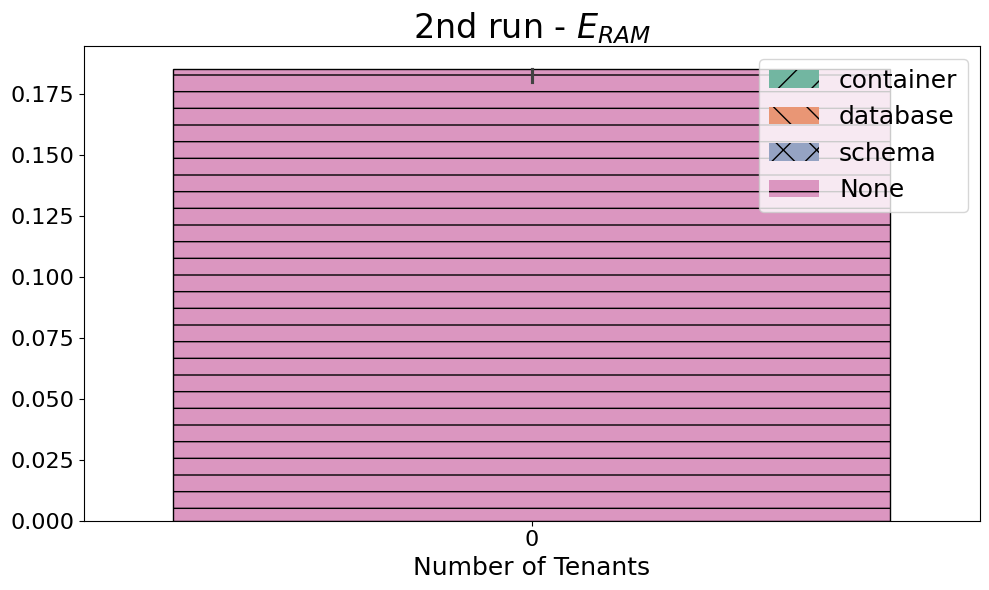

In [67]:
plot_bars(merged_df, y='E_RAM', title='2nd run - $E_{RAM}$', estimator='max', b_plot_save=b_plot_save, filename_prefix=filename_prefix)

In [68]:
#zip_all_results()